This document is inteded to showcase usage and allow the IBL team to acess example data until we decide about uploading the full dataset. The idea is to iterate and add improvemenets to the structure, suggest visualization and data access patterns that might be desirable for the final documentation.

To use it, you will need to run this notebook in an environment that has both pynwb and remfile installed plus any additional dependencies that we use for analysis such as matplotib, numpy, pandas, etc.

# Locate Examples

In [1]:
import h5py
import remfile
from pynwb import NWBHDF5IO
from dandi.dandiapi import DandiAPIClient

# Connect to DANDI and get the dandiset
dandiset_id = "000409"
client = DandiAPIClient()
dandiset = client.get_dandiset(dandiset_id, "draft")

# =============================================================================
# Session EIDs for NEW format files (desc-raw / desc-processed)
# =============================================================================

# Complete session with 2 probes - Session 1 (NYU-39, 2021-05-10, angelakilab)
# - Full data: all videos, pose estimation, spike sorting for both probes
TWO_PROBE_SESSION_EID_1 = "6ed57216-498d-48a6-b48b-a243a34710ea"

# Complete session with 2 probes - Session 2 (NYU-39, 2021-05-11, angelakilab)
# - Full data: all videos, pose estimation, spike sorting for both probes
TWO_PROBE_SESSION_EID_2 = "35ed605c-1a1a-47b1-86ff-2b56144f55af"

# Complete session with 1 probe (NYU-46, 2021-06-25, angelakilab)  
# - Full data: all videos, pose estimation, spike sorting for probe01
ONE_PROBE_SESSION_EID = "64e3fb86-928c-4079-865c-b364205b502e"

# Choose which session to use
session_eid = TWO_PROBE_SESSION_EID_1  # Change to TWO_PROBE_SESSION_EID_2 or ONE_PROBE_SESSION_EID

# =============================================================================
# Fetch assets by EID
# =============================================================================

# First, filter assets by EID
session_assets = [asset for asset in dandiset.get_assets() if session_eid in asset.path]

# Then, extract raw and processed files
raw_asset = next((asset for asset in session_assets if "desc-raw" in asset.path), None)
processed_asset = next((asset for asset in session_assets if "desc-processed" in asset.path), None)

print(f"Session EID: {session_eid}")
print(f"\nRaw file:       {raw_asset.path if raw_asset else 'Not found'}")
print(f"Processed file: {processed_asset.path if processed_asset else 'Not found'}")

Session EID: 6ed57216-498d-48a6-b48b-a243a34710ea

Raw file:       sub-NYU-39/sub-NYU-39_ses-6ed57216-498d-48a6-b48b-a243a34710ea_desc-raw_ecephys.nwb
Processed file: sub-NYU-39/sub-NYU-39_ses-6ed57216-498d-48a6-b48b-a243a34710ea_desc-processed_behavior+ecephys.nwb


# Raw NWBFile 
In NWBFile the raw data is stored in a separate file from the processed data. The raw data file contains the acquisition module with the raw ephys data (both AP and LF bands), the link with the Video metadata (which includes properly aligned timestamps), and, when available, the NIDQ board data.

In [2]:
s3_url = raw_asset.get_content_url(follow_redirects=1, strip_query=False)
file_system = remfile.File(s3_url)
file = h5py.File(file_system, mode="r")

io = NWBHDF5IO(file=file)
nwbfile_raw = io.read()

nwbfile_raw

Data type,int16
Shape,"(109132602, 384)"
Array size,78.06 GiB
Chunk shape,"(13020, 384)"
Compression,gzip
Compression opts,4
Uncompressed size (bytes),83813838336
Compressed size (bytes),41280801811
Compression ratio,2.0303345540557385
Data type,float64
Shape,"(109132602,)"


## Locating and Accessing the AP and LF bands

In PyNWB the raw data is stored in the acquisition module as an ElectricalSeries. We can access the AP bands of each probe as follows and use the HTML representation to display the metada of the ElectricalSeries

In [3]:
probe_00_ap_series = nwbfile_raw.acquisition["ElectricalSeriesProbe00AP"]
probe_01_ap_series = nwbfile_raw.acquisition["ElectricalSeriesProbe01AP"]

probe_00_ap_series

Data type,int16
Shape,"(109132602, 384)"
Array size,78.06 GiB
Chunk shape,"(13020, 384)"
Compression,gzip
Compression opts,4
Uncompressed size (bytes),83813838336
Compressed size (bytes),41280801811
Compression ratio,2.0303345540557385
Data type,float64
Shape,"(109132602,)"


The LF bands can be accessed in a similar way:

In [4]:
probe_00_lf_series = nwbfile_raw.acquisition["ElectricalSeriesProbe00LF"]
probe_01_lf_series = nwbfile_raw.acquisition["ElectricalSeriesProbe01LF"]

probe_01_lf_series

Data type,int16
Shape,"(9094385, 384)"
Array size,6.50 GiB
Chunk shape,"(13020, 384)"
Compression,gzip
Compression opts,4
Uncompressed size (bytes),6984487680
Compressed size (bytes),3451346026
Compression ratio,2.023699631211652
Data type,float64
Shape,"(9094385,)"


Crucially, each of the ElectricalSeries has its own timestamps that are aligned to the common clock used across the entire NWBFile. Moreover, each of the ElectricalSeries is programatically linked to the corresponding probe metadata stored in the electrodes table. For example, we can access the electrodes table for probe 0 as follows:

In [5]:
probe_01_ap_series.electrodes.to_dataframe()

,location,group,electrode_name,contact_shapes,channel_name,rel_x,rel_y,probe_name,contact_ids,shank_ids,adc_group,adc_sample_order,group_name,x,y,z,imp,filtering
id,,,,,,,,,,,,,,,,,,
0,rubrospinal tract,Probe01 pynwb.ecephys.ElectrodeGroup at 0x5000...,e0,square,"AP0,LF0",16.0,0.0,Probe01,e0,,0,0,Probe01,10499.0,6611.0,3900.0,NaN,
1,rubrospinal tract,Probe01 pynwb.ecephys.ElectrodeGroup at 0x5000...,e1,square,"AP1,LF1",48.0,0.0,Probe01,e1,,1,0,Probe01,10499.0,6611.0,3900.0,NaN,
2,rubrospinal tract,Probe01 pynwb.ecephys.ElectrodeGroup at 0x5000...,e2,square,"AP2,LF2",0.0,20.0,Probe01,e2,,0,1,Probe01,10496.0,6591.0,3903.0,NaN,
3,rubrospinal tract,Probe01 pynwb.ecephys.ElectrodeGroup at 0x5000...,e3,square,"AP3,LF3",32.0,20.0,Probe01,e3,,1,1,Probe01,10496.0,6591.0,3903.0,NaN,
4,Medulla,Probe01 pynwb.ecephys.ElectrodeGroup at 0x5000...,e4,square,"AP4,LF4",16.0,40.0,Probe01,e4,,0,2,Probe01,10490.0,6573.0,3906.0,NaN,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,Inferior colliculus dorsal nucleus,Probe01 pynwb.ecephys.ElectrodeGroup at 0x5000...,e379,square,"AP379,LF379",32.0,3780.0,Probe01,e379,,31,9,Probe01,10086.0,2919.0,4463.0,NaN,
380,Inferior colliculus dorsal nucleus,Probe01 pynwb.ecephys.ElectrodeGroup at 0x5000...,e380,square,"AP380,LF380",16.0,3800.0,Probe01,e380,,30,10,Probe01,10081.0,2901.0,4469.0,NaN,
381,Inferior colliculus dorsal nucleus,Probe01 pynwb.ecephys.ElectrodeGroup at 0x5000...,e381,square,"AP381,LF381",48.0,3800.0,Probe01,e381,,31,10,Probe01,10081.0,2901.0,4469.0,NaN,


## Electrode Metadata
The electrodes attribute of an ElectricalSeries is a region of the more general electrodes table stored in the NWBFile. This table contains all the metadata about each of the channels recorded by the probe, including their location in the brain, their position in the probe shank, and other relevant information. A convenient way to access this information is to convert the table to a pandas dataframe as follows:

In [6]:
electrodes = nwbfile_raw.electrodes
electrodes

,location,group,electrode_name,contact_shapes,channel_name,rel_x,rel_y,probe_name,contact_ids,shank_ids,adc_group,adc_sample_order,group_name,x,y,z,imp,filtering
id,,,,,,,,,,,,,,,,,,
0,rubrospinal tract,"Probe01 pynwb.ecephys.ElectrodeGroup at 0x5000496784\nFields:\n description: Electrode group for probe01\n device: Probe01 pynwb.device.Device at 0x5000497424\nFields:\n description: A PRB_1_4_0480_1_C probe. Additional metadata: {""model_name"": ""PRB_1_4_0480_1_C"", ""manufacturer"": ""imec"", ""port"": ""4"", ""slot"": ""2"", ""part_number"": ""PRB_1_4_0480_1_C""}\n manufacturer: imec\n serial_number: 19076618512\n\n location: Unresolved\n",e0,square,"AP0,LF0",16.0,0.0,Probe01,e0,,0,0,Probe01,10499.0,6611.0,3900.0,NaN,
1,rubrospinal tract,"Probe01 pynwb.ecephys.ElectrodeGroup at 0x5000496784\nFields:\n description: Electrode group for probe01\n device: Probe01 pynwb.device.Device at 0x5000497424\nFields:\n description: A PRB_1_4_0480_1_C probe. Additional metadata: {""model_name"": ""PRB_1_4_0480_1_C"", ""manufacturer"": ""imec"", ""port"": ""4"", ""slot"": ""2"", ""part_number"": ""PRB_1_4_0480_1_C""}\n manufacturer: imec\n serial_number: 19076618512\n\n location: Unresolved\n",e1,square,"AP1,LF1",48.0,0.0,Probe01,e1,,1,0,Probe01,10499.0,6611.0,3900.0,NaN,
2,rubrospinal tract,"Probe01 pynwb.ecephys.ElectrodeGroup at 0x5000496784\nFields:\n description: Electrode group for probe01\n device: Probe01 pynwb.device.Device at 0x5000497424\nFields:\n description: A PRB_1_4_0480_1_C probe. Additional metadata: {""model_name"": ""PRB_1_4_0480_1_C"", ""manufacturer"": ""imec"", ""port"": ""4"", ""slot"": ""2"", ""part_number"": ""PRB_1_4_0480_1_C""}\n manufacturer: imec\n serial_number: 19076618512\n\n location: Unresolved\n",e2,square,"AP2,LF2",0.0,20.0,Probe01,e2,,0,1,Probe01,10496.0,6591.0,3903.0,NaN,
3,rubrospinal tract,"Probe01 pynwb.ecephys.ElectrodeGroup at 0x5000496784\nFields:\n description: Electrode group for probe01\n device: Probe01 pynwb.device.Device at 0x5000497424\nFields:\n description: A PRB_1_4_0480_1_C probe. Additional metadata: {""model_name"": ""PRB_1_4_0480_1_C"", ""manufacturer"": ""imec"", ""port"": ""4"", ""slot"": ""2"", ""part_number"": ""PRB_1_4_0480_1_C""}\n manufacturer: imec\n serial_number: 19076618512\n\n location: Unresolved\n",e3,square,"AP3,LF3",32.0,20.0,Probe01,e3,,1,1,Probe01,10496.0,6591.0,3903.0,NaN,


Dynamic Table objects such as the electrodes table (but also the Units and Trials tables) can be easily converted to pandas dataframes for easier access and manipulation.


In [7]:
electrodes_df = electrodes.to_dataframe()
electrodes_df.columns

Index(['location', 'group', 'electrode_name', 'contact_shapes', 'channel_name',
       'rel_x', 'rel_y', 'probe_name', 'contact_ids', 'shank_ids', 'adc_group',
       'adc_sample_order', 'group_name', 'x', 'y', 'z', 'imp', 'filtering'],
      dtype='object')

Specially useful columns includes 'x', 'y', and 'z' which contain the coordinates of each electrode in the Allen CCF space. Where x is the anterior-posterior axis (AP), y is the dorsal-ventral axis (DV), and z is the medial-lateral axis (ML). In addition, the location column contains the full name of the brain region where each electrode is located. Another useful property are the coordinates `rel_x` and `rel_y` which contain the position of each electrode in the probe shank (relative to the probe) and can be used to visualize the probe geometry. Note that all the position columns are in units of micrometers. Finally, the electrode table also contains the probe name which can be used to filter the table by probe.



In [8]:
columns = ["probe_name", "location", "x", "y", "z", "rel_x", "rel_y"]
electrodes_df[columns].sample(n=5)

,probe_name,location,x,y,z,rel_x,rel_y
id,,,,,,,
558,Probe00,Dentate gyrus molecular layer,7497.0,2637.0,3997.0,0.0,1740.0
614,Probe00,Dentate gyrus molecular layer,7396.0,2079.0,3848.0,0.0,2300.0
653,Probe00,Field CA1,7323.0,1695.0,3775.0,48.0,2680.0
134,Probe01,Motor nucleus of trigeminal,10272.0,5310.0,4080.0,0.0,1340.0
633,Probe00,Field CA1,7366.0,1896.0,3818.0,48.0,2480.0


## Anatomical Location
More detailed anatomical location information is stored in the localization module

In [9]:
localization = nwbfile_raw.lab_meta_data["localization"]
localization

localization abc.Localization at 0x5095197056
Fields:
  anatomical_coordinates_tables: {
    ElectrodesCCFv3 <class 'abc.AnatomicalCoordinatesTable'>,
    ElectrodesIBLBregma <class 'abc.AnatomicalCoordinatesTable'>
  }
  spaces: {
    AllenCCFv3 <class 'abc.AllenCCFv3Space'>,
    IBLBregma <class 'abc.Space'>
  }

These module contains two coordinate tables linking the electrodes to their anatomical locations in the Allen CCF space and in the IBL virtual bregma centered space. As wiht the electrodes table, these tables can be converted to pandas dataframes for easier access and manipulation.

In [10]:
ccf_table_df = localization.anatomical_coordinates_tables["ElectrodesCCFv3"].to_dataframe()
ibl_bregma_table_df = localization.anatomical_coordinates_tables["ElectrodesIBLBregma"].to_dataframe()

ccf_table_df.columns

Index(['x', 'y', 'z', 'localized_entity', 'probe_name', 'brain_region'], dtype='object')

In [11]:
ccf_table_df.sample(n=5)

,x,y,z,localized_entity,probe_name,brain_region
id,,,,,,
531,7535.0,2911.0,4073.0,location...,Probe00,LP
597,7430.0,2261.0,3889.0,location \ id ...,Probe00,DG-mo
656,7313.0,1655.0,3765.0,location ...,Probe00,CA1
52,10404.0,6112.0,3997.0,location \ id ...,Probe01,PARN
11,10472.0,6516.0,3915.0,location ...,Probe01,MY


The tables provide the localization of each electrode in different coordinate systems and can be used for more detailed anatomical analyses and visualizations. For example, both tables contain the `probe_name` column which can be used to identify the probe associated with each electrode. In addition, the `ElectrodesIBLBregma` contains the localization in the Cosmos and Beryl spaces that should facilitate certain type of analyses and visualizations.

The localized_entity is a dynamic table region that links back to the electrodes table in the NWBFile. This allows us to easily access the electrode metadata for each of the localized electrodes.

## Anatomical Location of Probe Structure

We can illustrate  how to combine the information from the anatomical coordinates table with the metadata contained in the electrodes table to create a visualization that combines the relative positions of the electrodes plus the atlas information. This allows us to see what areas does the probe traverse. We use here the Cosmos parcellation for this visualization as that provides an overall and easy view of the probe localization.

Found 2 probe(s): ['Probe00', 'Probe01']


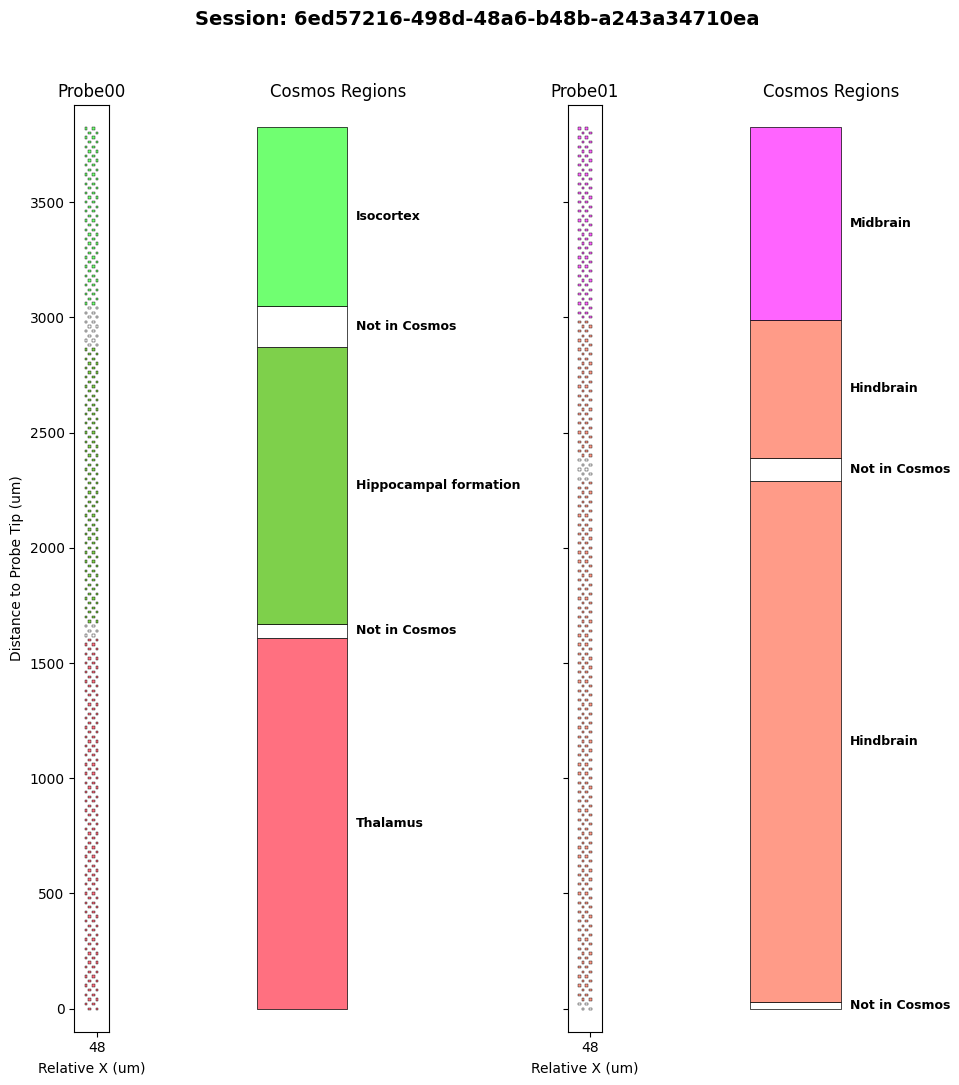

In [12]:
import matplotlib.pyplot as plt

from ibl_to_nwb.utils import COSMOS_FULL_NAMES, get_cosmos_color

nwbfile = nwbfile_raw

# %% Get anatomical localization table
anatomical_tables = localization.anatomical_coordinates_tables
ibl_bregma_table_df = anatomical_tables["ElectrodesIBLBregma"].to_dataframe()

# %% Get all unique probe names
probe_names = sorted(ibl_bregma_table_df["probe_name"].unique())
n_probes = len(probe_names)

print(f"Found {n_probes} probe(s): {probe_names}")

# %% Create figure - 2 columns per probe (contacts + regions), side by side
fig, axes = plt.subplots(1, n_probes * 2, figsize=(5 * n_probes, 12), sharey=True)

# Handle single probe case (axes won't be a list)
if n_probes == 1:
    axes = [axes[0], axes[1]]

# Track all unique regions across all probes for the legend
all_unique_regions = []

# %% Plot each probe
for probe_index, probe_name in enumerate(probe_names):
    # Get axes for this probe
    ax_probe = axes[probe_index * 2]
    ax_regions = axes[probe_index * 2 + 1]

    # Filter data for this probe
    probe_table = ibl_bregma_table_df[ibl_bregma_table_df["probe_name"] == probe_name].copy()

    # Extract electrode positions from localized_entity
    probe_table["rel_x"] = [electrode["rel_x"].iloc[0] for electrode in probe_table["localized_entity"]]
    probe_table["rel_y"] = [electrode["rel_y"].iloc[0] for electrode in probe_table["localized_entity"]]

    # Sort by depth (rel_y)
    probe_table = probe_table.sort_values("rel_y").reset_index(drop=True)

    # Precompute colors
    cosmos_values = probe_table["cosmos_location"].values
    rel_x_values = probe_table["rel_x"].values
    rel_y_values = probe_table["rel_y"].values
    colors = [get_cosmos_color(c) for c in cosmos_values]

    # Track unique regions for legend
    for region in cosmos_values:
        if region not in all_unique_regions:
            all_unique_regions.append(region)

    # --- Left panel: Probe contacts ---
    contact_width = 12  # um
    contact_height = 10  # um

    for i in range(len(rel_x_values)):
        rect = plt.Rectangle(
            (rel_x_values[i] - contact_width / 2, rel_y_values[i] - contact_height / 2),
            contact_width,
            contact_height,
            facecolor=colors[i],
            edgecolor="black",
            linewidth=0.3,
        )
        ax_probe.add_patch(rect)

    # Set probe axis limits
    x_min, x_max = probe_table["rel_x"].min(), probe_table["rel_x"].max()
    y_min, y_max = probe_table["rel_y"].min(), probe_table["rel_y"].max()
    x_margin, y_margin = 50, 100

    ax_probe.set_xlim(x_min - x_margin, x_max + x_margin)
    ax_probe.set_ylim(y_min - y_margin, y_max + y_margin)
    
    # Simplify x-axis: single tick at max value
    ax_probe.set_xticks([x_max])
    ax_probe.set_xticklabels([f"{x_max:.0f}"])
    ax_probe.set_xlabel("Relative X (um)")
    
    if probe_index == 0:
        ax_probe.set_ylabel("Distance to Probe Tip (um)")
    ax_probe.set_title(f"{probe_name}")
    ax_probe.set_aspect("equal", adjustable="box")

    # --- Right panel: Region blocks ---
    blocks = []
    current_region = cosmos_values[0]
    block_start = rel_y_values[0]

    for i in range(1, len(cosmos_values)):
        if cosmos_values[i] != current_region:
            block_end = (rel_y_values[i - 1] + rel_y_values[i]) / 2
            blocks.append((current_region, block_start, block_end))
            current_region = cosmos_values[i]
            block_start = block_end

    # Add final block
    blocks.append((current_region, block_start, rel_y_values[-1] + contact_height / 2))

    # Plot region blocks
    block_width = 1.0
    for region, y_start, y_end in blocks:
        color = get_cosmos_color(region)
        height = y_end - y_start

        rect = plt.Rectangle(
            (0, y_start),
            block_width,
            height,
            facecolor=color,
            edgecolor="black",
            linewidth=0.5,
        )
        ax_regions.add_patch(rect)

        # Add label in the middle of the block
        y_center = (y_start + y_end) / 2
        display_name = COSMOS_FULL_NAMES.get(region, region)
        ax_regions.text(block_width + 0.1, y_center, display_name, va="center", ha="left", fontsize=9, fontweight="bold")

    ax_regions.set_xlim(-0.2, 2.0)
    ax_regions.set_ylim(y_min - y_margin, y_max + y_margin)
    ax_regions.set_xticks([])
    ax_regions.set_title("Cosmos Regions")
    ax_regions.axis("off")

# %% Add legend and title
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=get_cosmos_color(r), edgecolor="black", linewidth=0.5)
    for r in all_unique_regions
]
legend_labels = [COSMOS_FULL_NAMES.get(r, r) for r in all_unique_regions]


plt.suptitle(f"Session: {nwbfile.session_id}", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0.08, 1, 0.96])

plt.show()

## Anatomical Location of Probes in the CCFv3 space
To get an overview of where the probes are located in the brain we can use brainrender to visualize the probe shanks together with the brain regions they traverse. Here is an example of how to do this for one of the probes using the Cosmos parcellation.

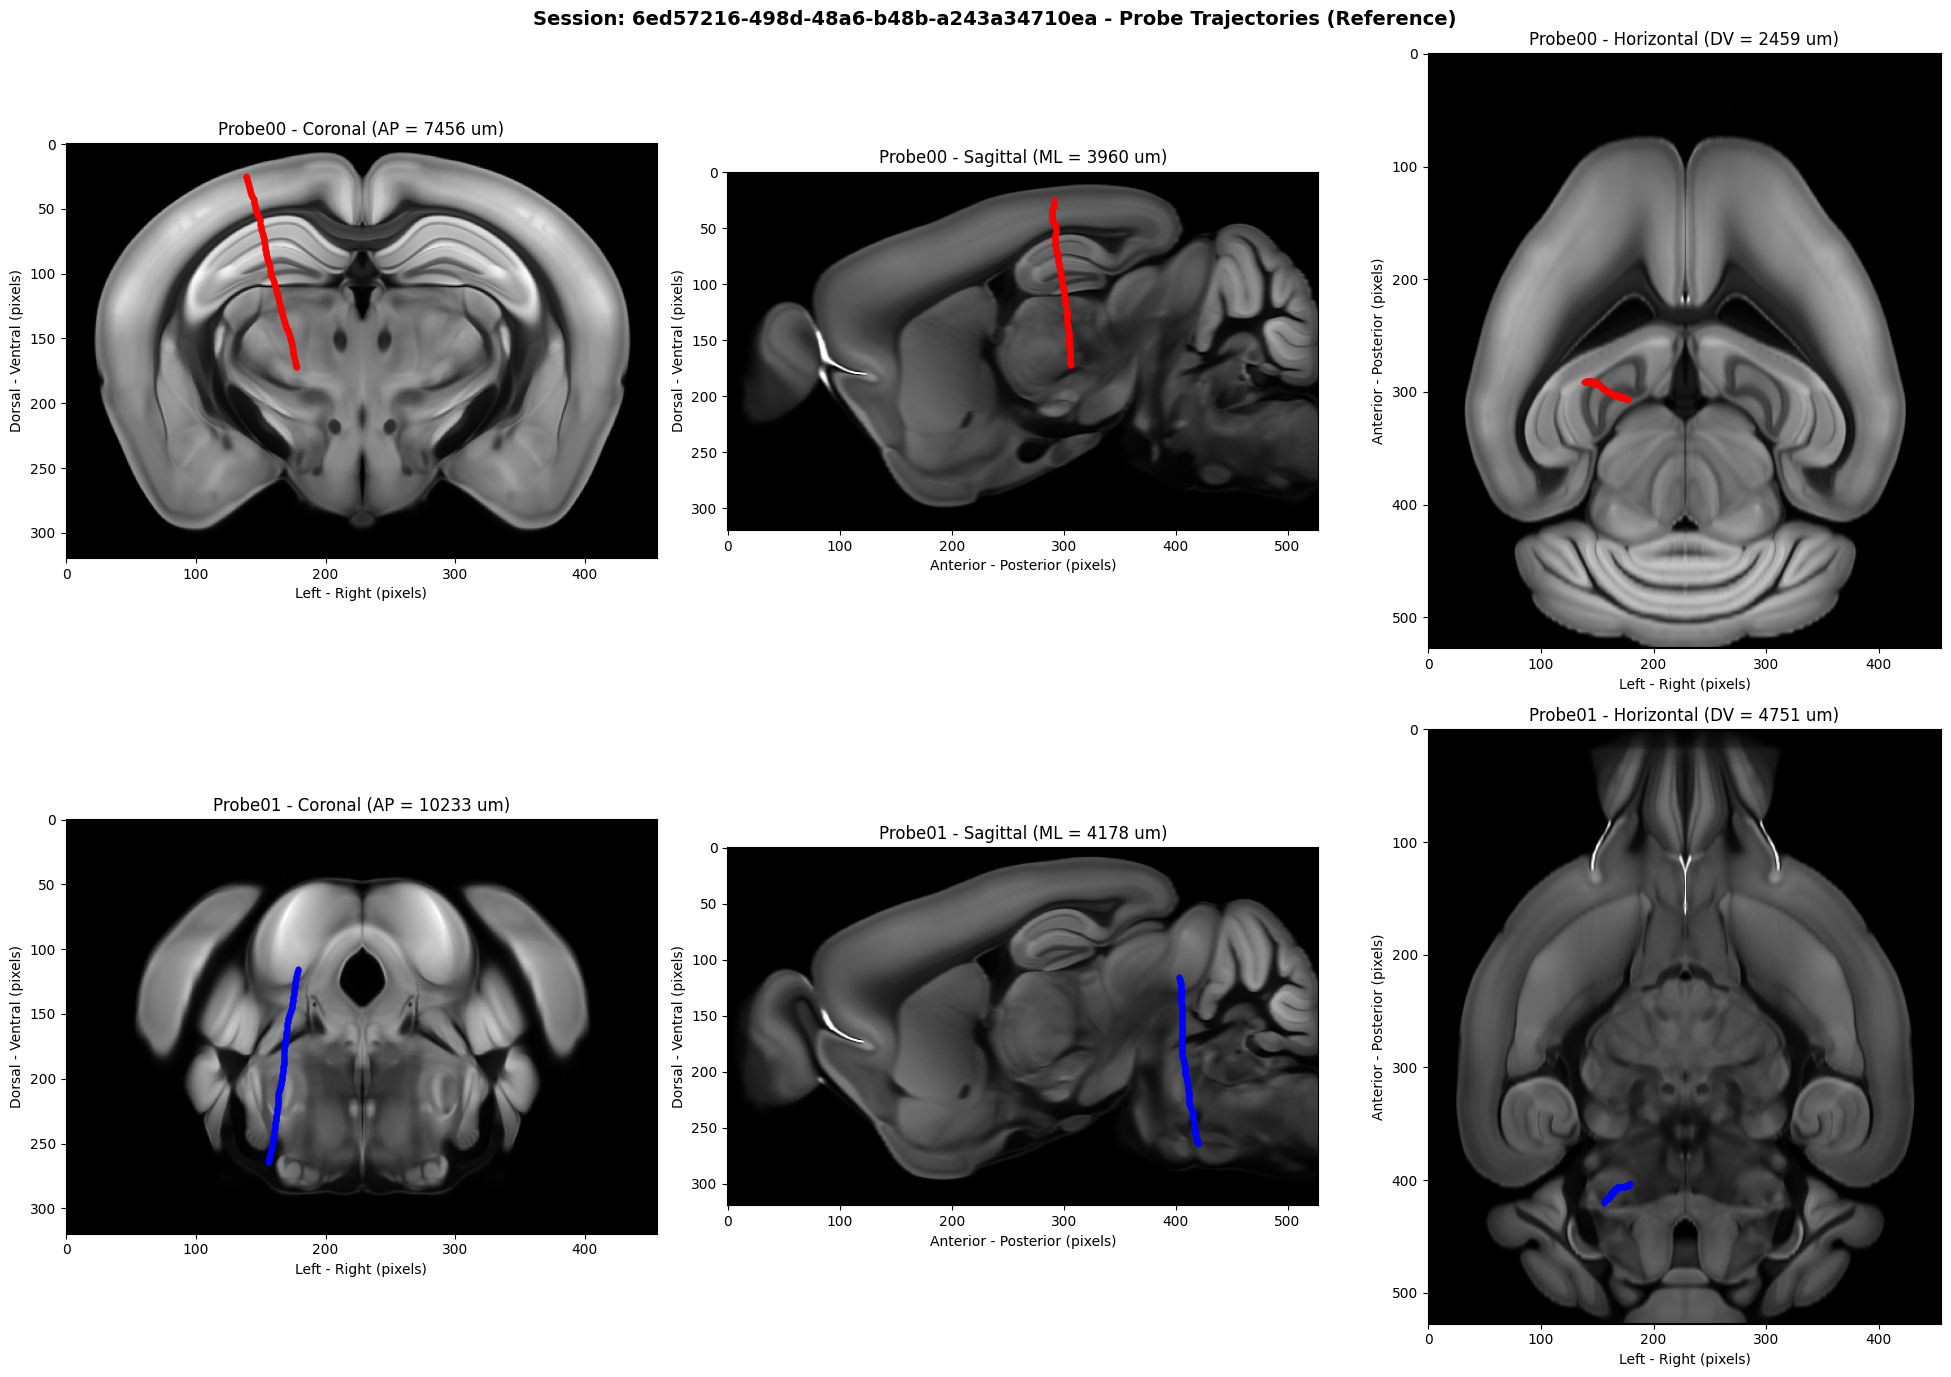

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from brainglobe_atlasapi import BrainGlobeAtlas

# %% Get CCFv3 coordinates for all probes
anatomical_tables = localization.anatomical_coordinates_tables
ccf_table_df = anatomical_tables["ElectrodesCCFv3"].to_dataframe()

# Get all unique probe names
probe_names = sorted(ccf_table_df["probe_name"].unique())
n_probes = len(probe_names)

# Define colors for each probe
probe_colors = ["red", "blue", "green", "orange", "purple"][:n_probes]

# %% Load atlas
atlas = BrainGlobeAtlas("allen_mouse_25um")

# %% Collect probe data - compute slice positions per probe (mean coordinate approach)
# See documentation/probe_slice_visualization_guide.md for heuristics
probe_data = {}

for probe_name in probe_names:
    probe_table = ccf_table_df[ccf_table_df["probe_name"] == probe_name].copy()
    bg_x = probe_table["x"].values  # Anterior (0) to Posterior (13200)
    bg_y = probe_table["y"].values  # Dorsal (0) to Ventral (8000)
    bg_z = probe_table["z"].values  # Left (0) to Right (11400)
    
    # Calculate slice positions for this specific probe (mean coordinate)
    coronal_position = int(np.mean(bg_x))
    sagittal_position = int(np.mean(bg_z))
    horizontal_position = int(np.mean(bg_y))
    
    # Convert to slice indices
    coronal_index = int(coronal_position / atlas.resolution[0])
    sagittal_index = int(sagittal_position / atlas.resolution[2])
    horizontal_index = int(horizontal_position / atlas.resolution[1])
    
    probe_data[probe_name] = {
        "x_px": bg_x / atlas.resolution[0],
        "y_px": bg_y / atlas.resolution[1],
        "z_px": bg_z / atlas.resolution[2],
        "coronal_position": coronal_position,
        "sagittal_position": sagittal_position,
        "horizontal_position": horizontal_position,
        "coronal_index": coronal_index,
        "sagittal_index": sagittal_index,
        "horizontal_index": horizontal_index,
    }

# %% Create Figure: Grid with n_probes rows x 3 columns (one row per probe)
fig, axes = plt.subplots(n_probes, 3, figsize=(20, 7 * n_probes))

# Handle single probe case (axes won't be 2D)
if n_probes == 1:
    axes = axes.reshape(1, -1)

for row, probe_name in enumerate(probe_names):
    data = probe_data[probe_name]
    color = probe_colors[row]
    
    # Get slices centered on this probe's location
    reference_coronal = atlas.reference[data["coronal_index"], :, :]
    reference_sagittal = atlas.reference[:, :, data["sagittal_index"]]
    reference_horizontal = atlas.reference[:, data["horizontal_index"], :]
    
    # Coronal view
    ax = axes[row, 0]
    ax.imshow(reference_coronal, cmap="gray", aspect="equal")
    ax.scatter(data["z_px"], data["y_px"], c=color, s=10, alpha=0.8)
    ax.set_xlabel("Left - Right (pixels)")
    ax.set_ylabel("Dorsal - Ventral (pixels)")
    ax.set_title(f"{probe_name} - Coronal (AP = {data['coronal_position']} um)")
    
    # Sagittal view (transposed for correct orientation)
    ax = axes[row, 1]
    ax.imshow(reference_sagittal.T, cmap="gray", aspect="equal")
    ax.scatter(data["x_px"], data["y_px"], c=color, s=10, alpha=0.8)
    ax.set_xlabel("Anterior - Posterior (pixels)")
    ax.set_ylabel("Dorsal - Ventral (pixels)")
    ax.set_title(f"{probe_name} - Sagittal (ML = {data['sagittal_position']} um)")
    
    # Horizontal view
    ax = axes[row, 2]
    ax.imshow(reference_horizontal, cmap="gray", aspect="equal")
    ax.scatter(data["z_px"], data["x_px"], c=color, s=10, alpha=0.8)
    ax.set_xlabel("Left - Right (pixels)")
    ax.set_ylabel("Anterior - Posterior (pixels)")
    ax.set_title(f"{probe_name} - Horizontal (DV = {data['horizontal_position']} um)")

fig.suptitle(f"Session: {nwbfile_raw.session_id} - Probe Trajectories (Reference)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Both the electrode and the anatomical coordinates tables are present both nwbfiles (the one with the raw data and the one with the processed data) and are identical in both files.

## Accessing Video Data

In [14]:
# Get S3 URLs for each available camera
# The video paths are stored as relative paths in the ImageSeries external_file attribute
# We resolve them to full DANDI asset paths and get the S3 URLs

from pathlib import Path

# Get the parent directory of the NWB file (videos are stored relative to this)
nwb_parent = Path(raw_asset.path).parent

# Find all video ImageSeries and get their S3 URLs
video_s3_urls = {}
for name, obj in nwbfile_raw.acquisition.items():
    if hasattr(obj, 'external_file') and obj.external_file is not None:
        # Get the relative path and resolve it to a full DANDI path
        relative_path = obj.external_file[0].lstrip('./')
        full_path = str(nwb_parent / relative_path)
        
        # Fetch the asset directly from the dandiset by path
        video_asset = dandiset.get_asset_by_path(full_path)
        if video_asset is not None:
            video_s3_urls[name] = video_asset.get_content_url(follow_redirects=1, strip_query=True)

video_s3_urls

{'VideoBodyCamera': 'https://dandiarchive.s3.amazonaws.com/blobs/7f8/b5c/7f8b5c2a-3392-412e-8434-94d2c3883622',
 'VideoLeftCamera': 'https://dandiarchive.s3.amazonaws.com/blobs/267/135/267135c8-546a-49cf-bba9-6903c0b98d42',
 'VideoRightCamera': 'https://dandiarchive.s3.amazonaws.com/blobs/ac6/137/ac613719-2106-4a89-b134-0583a709f941'}

In [15]:
# Stream a video directly in the notebook using IPython HTML display
# This works but might have limitations in some notebook environments
from IPython.display import HTML

camera_to_display = "VideoLeftCamera"

if camera_to_display in video_s3_urls:
    video_url = video_s3_urls[camera_to_display]
    display(HTML(f"""
    <video width="640" height="480" controls>
        <source src="{video_url}" type="video/mp4">
        Your browser does not support the video tag.
    </video>
    <p><b>{camera_to_display}</b></p>
    """))
else:
    print(f"{camera_to_display} not available for this session")

While IPython's HTML display works for basic video playback, anywidget provides a more robust, cross-platform solution. Anywidget allows you to build interactive widgets that work seamlessly across JupyterLab, Jupyter Notebook, VS Code, Google Colab, and other notebook environments without platform-specific workarounds. This ensures consistent widget functionality and appearance regardless of which notebook environment you use. The custom MultiVideoPlayer widget below leverages anywidget to provide synchronized multi-camera video playback with unified controls.

In [16]:
import anywidget
import traitlets

class MultiVideoPlayer(anywidget.AnyWidget):
    """Display all available camera videos side by side with synchronized playback."""
    
    video_urls = traitlets.Dict({}).tag(sync=True)
    
    _esm = """
    function render({ model, el }) {
        const wrapper = document.createElement('div');
        wrapper.style.fontFamily = 'sans-serif';
        
        // Control bar
        const controls = document.createElement('div');
        controls.style.marginBottom = '10px';
        controls.style.display = 'flex';
        controls.style.alignItems = 'center';
        controls.style.gap = '10px';
        
        const playPauseBtn = document.createElement('button');
        playPauseBtn.textContent = 'Play All';
        playPauseBtn.style.padding = '8px 16px';
        playPauseBtn.style.fontSize = '14px';
        playPauseBtn.style.cursor = 'pointer';
        
        const seekBar = document.createElement('input');
        seekBar.type = 'range';
        seekBar.min = 0;
        seekBar.max = 100;
        seekBar.value = 0;
        seekBar.style.flex = '1';
        
        const timeLabel = document.createElement('span');
        timeLabel.textContent = '0:00 / 0:00';
        timeLabel.style.fontSize = '12px';
        timeLabel.style.minWidth = '100px';
        
        controls.appendChild(playPauseBtn);
        controls.appendChild(seekBar);
        controls.appendChild(timeLabel);
        
        // Video container - force horizontal row layout
        const container = document.createElement('div');
        container.style.display = 'flex';
        container.style.flexDirection = 'row';
        container.style.gap = '10px';
        container.style.flexWrap = 'nowrap';
        
        let videos = [];
        let isPlaying = false;
        
        // Define the desired order: Left, Body (center), Right
        const cameraOrder = ['VideoLeftCamera', 'VideoBodyCamera', 'VideoRightCamera'];
        
        function formatTime(seconds) {
            const mins = Math.floor(seconds / 60);
            const secs = Math.floor(seconds % 60);
            return mins + ':' + secs.toString().padStart(2, '0');
        }
        
        function updateVideos() {
            container.innerHTML = '';
            videos = [];
            const urls = model.get('video_urls');
            
            // Sort by predefined order
            const sortedEntries = cameraOrder
                .filter(name => name in urls)
                .map(name => [name, urls[name]]);
            
            for (const [name, url] of sortedEntries) {
                const videoContainer = document.createElement('div');
                videoContainer.style.textAlign = 'center';
                videoContainer.style.display = 'inline-block';
                
                const video = document.createElement('video');
                video.width = 320;
                video.height = 240;
                video.style.display = 'block';
                video.style.backgroundColor = '#000';
                video.src = url;
                video.muted = true;  // Mute to allow autoplay
                videos.push(video);
                
                const label = document.createElement('p');
                label.textContent = name.replace('Video', '').replace('Camera', '');
                label.style.fontWeight = 'bold';
                label.style.margin = '5px 0';
                
                videoContainer.appendChild(video);
                videoContainer.appendChild(label);
                container.appendChild(videoContainer);
            }
            
            // Update seek bar max when metadata loads
            if (videos.length > 0) {
                videos[0].addEventListener('loadedmetadata', () => {
                    seekBar.max = videos[0].duration;
                    timeLabel.textContent = '0:00 / ' + formatTime(videos[0].duration);
                });
                videos[0].addEventListener('timeupdate', () => {
                    if (!seekBar.matches(':active')) {
                        seekBar.value = videos[0].currentTime;
                    }
                    timeLabel.textContent = formatTime(videos[0].currentTime) + ' / ' + formatTime(videos[0].duration);
                });
            }
        }
        
        playPauseBtn.addEventListener('click', () => {
            if (isPlaying) {
                videos.forEach(v => v.pause());
                playPauseBtn.textContent = 'Play All';
            } else {
                videos.forEach(v => v.play());
                playPauseBtn.textContent = 'Pause All';
            }
            isPlaying = !isPlaying;
        });
        
        seekBar.addEventListener('input', () => {
            const time = parseFloat(seekBar.value);
            videos.forEach(v => v.currentTime = time);
        });
        
        model.on('change:video_urls', updateVideos);
        updateVideos();
        
        wrapper.appendChild(controls);
        wrapper.appendChild(container);
        el.appendChild(wrapper);
    }
    export default { render };
    """

MultiVideoPlayer(video_urls=video_s3_urls)

# Processed files

The processed file contains the processed data including the spike sorting results, the trials information, the pose estimation results, the wheel position, lick times and other behavioral data.

In [17]:
s3_url = processed_asset.get_content_url(follow_redirects=1, strip_query=False)
file_system = remfile.File(s3_url)
file = h5py.File(file_system, mode="r")

io = NWBHDF5IO(file=file)
nwbfile_processed = io.read()

nwbfile_processed

root pynwb.file.NWBFile at 0x14615559888
Fields:
  devices: {
    Probe00 <class 'pynwb.device.Device'>,
    Probe01 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    Probe00 <class 'pynwb.ecephys.ElectrodeGroup'>,
    Probe01 <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  epochs: epochs <class 'pynwb.epoch.TimeIntervals'>
  file_create_date: [datetime.datetime(2026, 1, 6, 0, 55, 2, 516440, tzinfo=tzutc())]
  identifier: b2002ac7-c307-4f1e-93d5-3bc1f40239d0
  institution: New York University / Center for Neural Science
  intervals: {
    epochs <class 'pynwb.epoch.TimeIntervals'>,
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  lab: angelakilab
  lab_meta_data: {
    ibl_bwm_metadata <class 'abc.ibl_bwm_metadata'>,
    ibl_probe_insertion_trajectories <class 'abc.IblProbeInsertionTrajectories'>,
    localization <class 'abc.Localization'>
  }
  processing: {
    lick_times <class 'pynwb.base.ProcessingModule'>,
    passive_protocol <class 'pynwb.base.ProcessingModule'>,
    pose_estimation <class 'pynwb.base.ProcessingModule'>,
    video <class 'pynwb.base.ProcessingModule'>,
    wheel <class 'pynwb.base.ProcessingModule'>
  }
  protocol: _iblrig_tasks_ephysChoiceWorld6.4.2
  session_id: 6ed57216-498d-48a6-b48b-a243a34710ea
  session_start_time: 2021-05-10 14:33:49.023776-04:00
  source_script: Created using NeuroConv v0.9.1
  source_script_file_name: /ebs/IBL-to-nwb/.venv/lib/python3.10/site-packages/neuroconv/basedatainterface.py
  subject: subject abc.IblSubject at 0x14444018528
Fields:
  age__reference: birth
  date_of_birth: 2020-12-08 00:00:00-05:00
  expected_water_ml: 0.856
  remaining_water_ml: 0.856
  sex: M
  species: Mus musculus
  subject_id: NYU-39
  uuid: ccb12ddd-95c4-4fc0-956f-db2f8cdcd26d
  weight: 0.022 kg

  timestamps_reference_time: 2021-05-10 14:33:49.023776-04:00
  trials: trials <class 'pynwb.epoch.TimeIntervals'>
  units: units <class 'pynwb.misc.Units'>

We can get general information about the session as follows:

In [18]:
session_start_time = nwbfile_processed.session_start_time
eid = nwbfile_processed.session_id
number_of_trials = len(nwbfile_processed.trials)
number_of_units = len(nwbfile_processed.units)
lab = nwbfile_processed.lab

print(f"Session ID: {eid}")
print(f"Session Start Time: {session_start_time}")
print(f"Number of Trials: {number_of_trials}")
print(f"Number of Units: {number_of_units}")
print(f"Lab: {lab}")

Session ID: 6ed57216-498d-48a6-b48b-a243a34710ea
Session Start Time: 2021-05-10 14:33:49.023776-04:00
Number of Trials: 541
Number of Units: 1366
Lab: angelakilab


And the subject information is contained in the subject attribute:

In [19]:
subject = nwbfile_processed.subject
subject

subject abc.IblSubject at 0x14444018528
Fields:
  age__reference: birth
  date_of_birth: 2020-12-08 00:00:00-05:00
  expected_water_ml: 0.856
  remaining_water_ml: 0.856
  sex: M
  species: Mus musculus
  subject_id: NYU-39
  uuid: ccb12ddd-95c4-4fc0-956f-db2f8cdcd26d
  weight: 0.022 kg

## Epochs (Task vs Passive)

In [20]:
nwbfile.epochs

,start_time,stop_time,protocol_type,epoch_description
id,,,,
0,0.000000,2356.043459,task,Active behavioral task period. The mouse performs a decision-making task where it must turn a wheel to move a visual stimulus (Gabor patch) to the center of the screen. Correct responses are rewarded with water; incorrect responses trigger white noise feedback. The trials table contains detailed timing and outcome data for each trial during this epoch.
1,2356.043459,3637.565807,passive,"Passive stimulus replay period. Visual and auditory stimuli are presented while the mouse is head-fixed but not performing any task. This epoch includes: (1) replay of task-relevant stimuli (Gabor patches at various contrasts and positions), (2) sparse noise stimuli for receptive field mapping, and (3) natural movie clips. Used for characterizing sensory responses independent of task engagement."


In [21]:
epochs_df = nwbfile.epochs.to_dataframe()
epochs_df

,start_time,stop_time,protocol_type,epoch_description
id,,,,
0,0.000000,2356.043459,task,Active behavioral task period. The mouse perfo...
1,2356.043459,3637.565807,passive,Passive stimulus replay period. Visual and aud...


## Loading Spike Sorting Data
The spike sorting results are stored in the units table of the NWBFile. This table contains all the relevant information about each of the detected units including their spike times, waveform properties, quality metrics, and electrode provenance. The later can be used to link each unit to the corresponding electrode in the electrodes table which in turn can be used to link the unit to its anatomical location.

In [22]:
units = nwbfile_processed.units
units

units pynwb.misc.Units at 0x14662156368
Fields:
  colnames: ['spike_times' 'electrodes' 'waveform_mean' 'unit_name' 'probe_name'
 'presence_ratio_std' 'sliding_rp_violation' 'peak_to_trough_duration_ms'
 'missed_spikes_estimate' 'spike_count' 'presence_ratio'
 'ibl_quality_score' 'max_spike_amplitude_uV' 'min_spike_amplitude_uV'
 'noise_cutoff' 'cluster_uuid' 'isi_violations_ratio'
 'spike_amplitudes_uV' 'max_electrode' 'median_spike_amplitude_uV'
 'firing_rate' 'cumulative_drift_um_per_hour' 'spike_amplitude_std_dB'
 'kilosort2_label' 'spike_distances_from_probe_tip_um'
 'distance_from_probe_tip_um' 'rp_violation']
  columns: (
    spike_times_index <class 'hdmf.common.table.VectorIndex'>,
    spike_times <class 'hdmf.common.table.VectorData'>,
    electrodes_index <class 'hdmf.common.table.VectorIndex'>,
    electrodes <class 'hdmf.common.table.DynamicTableRegion'>,
    waveform_mean <class 'hdmf.common.table.VectorData'>,
    unit_name <class 'hdmf.common.table.VectorData'>,
    probe_name <class 'hdmf.common.table.VectorData'>,
    presence_ratio_std <class 'hdmf.common.table.VectorData'>,
    sliding_rp_violation <class 'hdmf.common.table.VectorData'>,
    peak_to_trough_duration_ms <class 'hdmf.common.table.VectorData'>,
    missed_spikes_estimate <class 'hdmf.common.table.VectorData'>,
    spike_count <class 'hdmf.common.table.VectorData'>,
    presence_ratio <class 'hdmf.common.table.VectorData'>,
    ibl_quality_score <class 'hdmf.common.table.VectorData'>,
    max_spike_amplitude_uV <class 'hdmf.common.table.VectorData'>,
    min_spike_amplitude_uV <class 'hdmf.common.table.VectorData'>,
    noise_cutoff <class 'hdmf.common.table.VectorData'>,
    cluster_uuid <class 'hdmf.common.table.VectorData'>,
    isi_violations_ratio <class 'hdmf.common.table.VectorData'>,
    spike_amplitudes_uV_index <class 'hdmf.common.table.VectorIndex'>,
    spike_amplitudes_uV <class 'hdmf.common.table.VectorData'>,
    max_electrode <class 'hdmf.common.table.DynamicTableRegion'>,
    median_spike_amplitude_uV <class 'hdmf.common.table.VectorData'>,
    firing_rate <class 'hdmf.common.table.VectorData'>,
    cumulative_drift_um_per_hour <class 'hdmf.common.table.VectorData'>,
    spike_amplitude_std_dB <class 'hdmf.common.table.VectorData'>,
    kilosort2_label <class 'hdmf.common.table.VectorData'>,
    spike_distances_from_probe_tip_um_index <class 'hdmf.common.table.VectorIndex'>,
    spike_distances_from_probe_tip_um <class 'hdmf.common.table.VectorData'>,
    distance_from_probe_tip_um <class 'hdmf.common.table.VectorData'>,
    rp_violation <class 'hdmf.common.table.VectorData'>
  )
  description: Spike-sorted units from Neuropixels 1.0 probes. Spike sorting was performed using a Python implementation of Kilosort 2.5 (iblsorter, formerly pykilosort) with IBL-specific optimizations for drift correction and automated quality control. Unit quality is determined by three metrics: (1) refractory period violations using the slidingRP algorithm (Hill et al. 2011), (2) noise cutoff based on amplitude distribution, and (3) median spike amplitude threshold (>50 uV). The 'label' column indicates the proportion of metrics passed (1.0 = all passed, i.e. 'good' unit). Each unit includes brain region assignment from IBL's histology pipeline with Allen CCF coordinates. For methodology details, see the IBL spike sorting white paper: https://doi.org/10.6084/m9.figshare.19705522
  id: id <class 'hdmf.common.table.ElementIdentifiers'>
  resolution: 3.3333333333333335e-05
  waveform_rate: 30000.0
  waveform_unit: microvolts


As usual we can convert the units table to a pandas dataframe for easier access and manipulation:

In [23]:
units_df = units.to_dataframe()
units_df.columns

Index(['spike_times', 'electrodes', 'waveform_mean', 'unit_name', 'probe_name',
       'presence_ratio_std', 'sliding_rp_violation',
       'peak_to_trough_duration_ms', 'missed_spikes_estimate', 'spike_count',
       'presence_ratio', 'ibl_quality_score', 'max_spike_amplitude_uV',
       'min_spike_amplitude_uV', 'noise_cutoff', 'cluster_uuid',
       'isi_violations_ratio', 'spike_amplitudes_uV', 'max_electrode',
       'median_spike_amplitude_uV', 'firing_rate',
       'cumulative_drift_um_per_hour', 'spike_amplitude_std_dB',
       'kilosort2_label', 'spike_distances_from_probe_tip_um',
       'distance_from_probe_tip_um', 'rp_violation'],
      dtype='object')

The following are particularly useful columns in the units table:

* **spike_times**: the spike times (in seconds) for each units referenced to the common clock of the NWBFile (session start time)
* **waveform_mean**: the average waveform of the unit across all spikes as calculated by the IBL spike sorting pipeline
* **probe_name**: the name of the probe where the unit was detected. 
* **max_electrodes**: the electrode where the unit has the maximum amplitude. This is a dynamic table region that can be used to link the unit to its anatomical location via the electrodes table.
* **electrodes**: all the electrodes assigned to the unit by the IBL team. This is a dynamic table region that links back to the electrodes table in the NWBFile.
* **ibl_quality_score**: Proportion of IBL quality metrics passed (0.0, 0.33, 0.67, or 1.0). 1.0 = all three passed.

In the following we analyze and visualize the spike sorting results for one of the probes in the session.

In [24]:
units_probe_df = units_df[units_df["probe_name"] == "Probe00"]
columns = ["unit_name", "cluster_uuid", "spike_count", "firing_rate", "kilosort2_label", "ibl_quality_score"]
units_probe_df[columns].sample(n=5)

,unit_name,cluster_uuid,spike_count,firing_rate,kilosort2_label,ibl_quality_score
id,,,,,,
108,probe00_108,8b4ad11c-e9e9-480e-bda0-144f566feb15,16311,4.483864,good,1.000000
250,probe00_250,82048621-cb26-4c06-8d04-b09c36c091fc,2288,0.628967,good,0.666667
75,probe00_75,9f63779f-6c2a-4062-b509-7ad8a627f8fb,22138,6.085695,good,1.000000
290,probe00_290,5b30fc36-a522-44cc-868b-04a96928e56b,15527,4.268344,mua,0.666667
262,probe00_262,fc914d9b-d3c8-442b-8e49-72237e4894a6,49091,13.495025,mua,0.000000


In [25]:
columns = ["unit_name", "median_spike_amplitude_uV", "distance_from_probe_tip_um"]
units_probe_df[columns].sample(n=5)

,unit_name,median_spike_amplitude_uV,distance_from_probe_tip_um
id,,,
147,probe00_147,63.561343,1120.0
124,probe00_124,62.544265,980.0
125,probe00_125,31.721714,980.0
130,probe00_130,67.050155,980.0
168,probe00_168,60.959378,1260.0


Number of good units on Probe01: 71


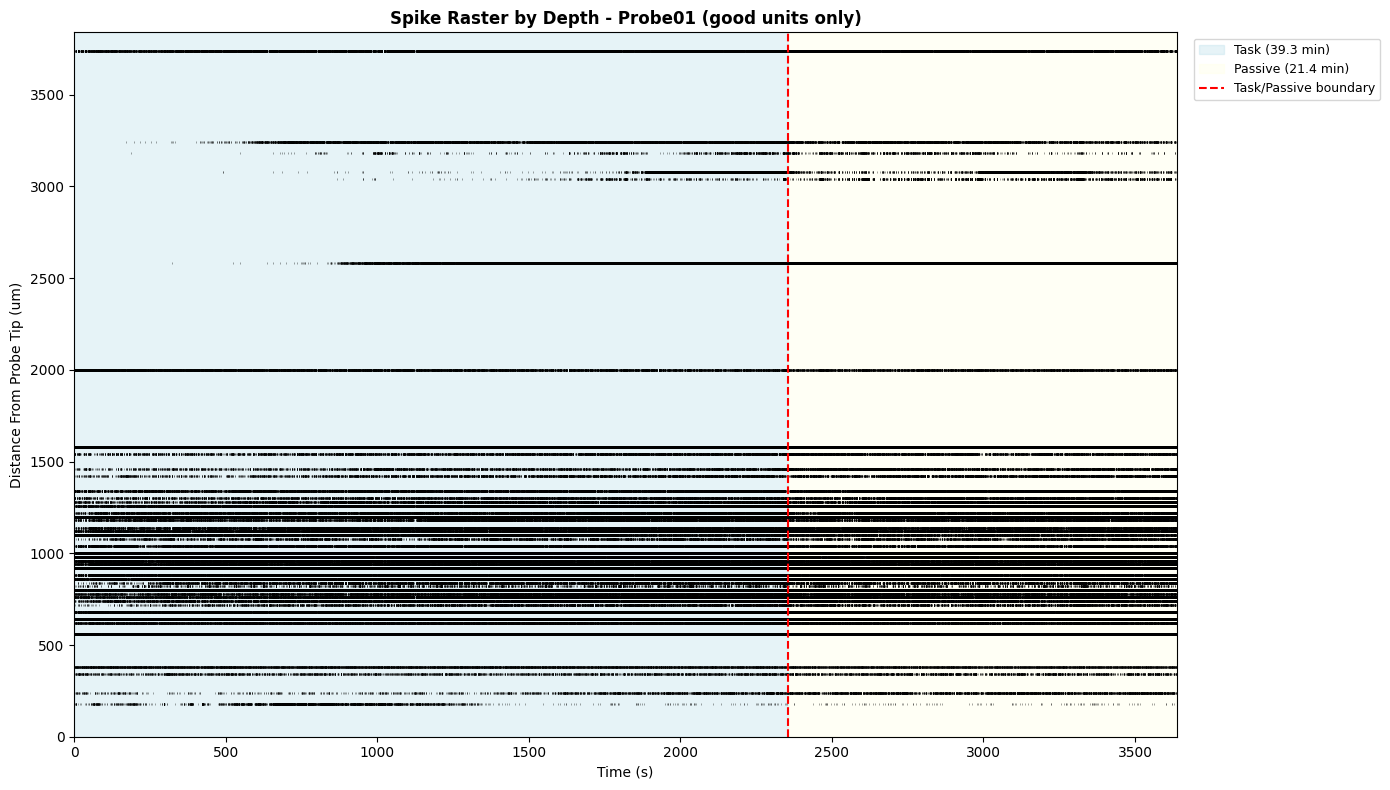

In [26]:
task_epoch = epochs_df[epochs_df['protocol_type'] == 'task'].iloc[0]
passive_epoch = epochs_df[epochs_df['protocol_type'] == 'passive'].iloc[0]

# Calculate durations for labels
task_duration = task_epoch['stop_time'] - task_epoch['start_time']
passive_duration = passive_epoch['stop_time'] - passive_epoch['start_time']

# Filter to good units only (IBL quality score == 1)
df = units_probe_df[units_probe_df['ibl_quality_score'] == 1].copy()
print(f"Number of good units on {probe_name}: {len(units_probe_df[units_probe_df['ibl_quality_score'] == 1])}")

# Sort units by depth
units_probe = df.sort_values('distance_from_probe_tip_um')

# Create figure
fig, ax = plt.subplots(figsize=(14, 8))

# Add epoch background colors with duration in labels
ax.axvspan(task_epoch['start_time'], task_epoch['stop_time'],
           color='lightblue', alpha=0.3, label=f'Task ({task_duration/60:.1f} min)')
ax.axvspan(passive_epoch['start_time'], passive_epoch['stop_time'],
           color='lightyellow', alpha=0.3, label=f'Passive ({passive_duration/60:.1f} min)')

# Plot spikes for each unit at its depth
for idx, (unit_id, unit) in enumerate(units_probe.iterrows()):
    spike_times = unit['spike_times']
    depth = unit['distance_from_probe_tip_um']

    # Plot all spikes
    ax.scatter(spike_times, np.full(len(spike_times), depth),
               c='black', s=1.0, marker='|', linewidths=0.5, alpha=0.5)

# Add epoch boundary line
ax.axvline(task_epoch['stop_time'], color='red', linestyle='--', linewidth=1.5, label='Task/Passive boundary')

# Labels and styling
ax.set_xlabel('Time (s)')
ax.set_ylabel('Distance From Probe Tip (um)')
ax.set_title(f'Spike Raster by Depth - {probe_name} (good units only)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, passive_epoch['stop_time'])
ax.set_ylim(0, units_probe['distance_from_probe_tip_um'].max() + 100)

# Keep y-axis normal (depth increases upward, deeper units at top)

# Add legend outside the plot
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)

plt.tight_layout()
plt.show()

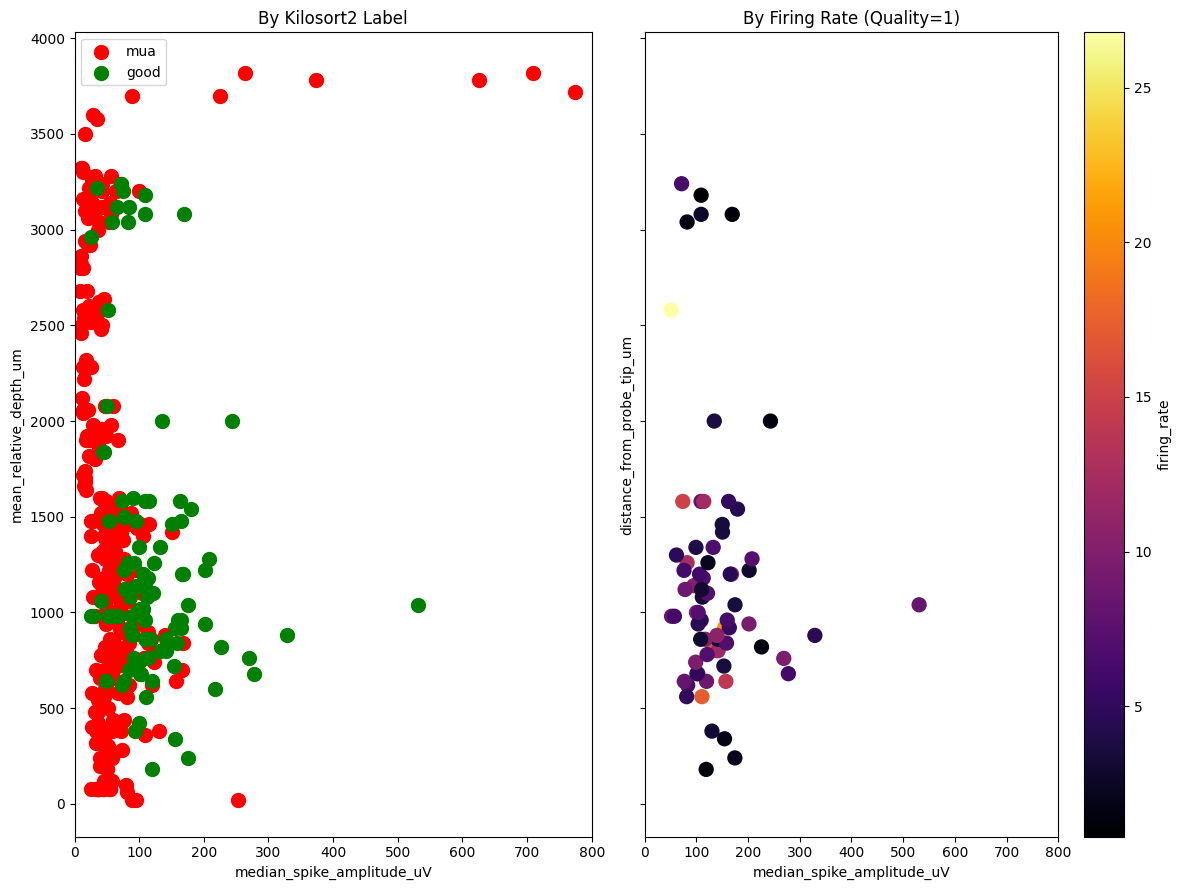

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 9), sharey=True)

# Left plot - colored by kilosort2_label
df = units_probe_df
value_to_color = {"mua": "red", "good": "green"}

for label, color in value_to_color.items():
    subset = df[df["kilosort2_label"] == label]
    axes[0].scatter(
        subset["median_spike_amplitude_uV"],
        subset["distance_from_probe_tip_um"],
        c=color,
        label=label,
        s=100,
    )
axes[0].set_xlim([0, 800])
axes[0].set_xlabel("median_spike_amplitude_uV")
axes[0].set_ylabel("mean_relative_depth_um")
axes[0].set_title("By Kilosort2 Label")
axes[0].legend()

# Right plot - colored by firing_rate
df = units_probe_df[units_probe_df["ibl_quality_score"] == 1]

df.plot.scatter(
    x="median_spike_amplitude_uV", 
    y="distance_from_probe_tip_um",
    c="firing_rate",
    colormap="inferno",
    s=100,
    ax=axes[1]
)
axes[1].set_xlim([0, 800])
axes[1].set_xlabel("median_spike_amplitude_uV")
axes[1].set_title("By Firing Rate (Quality=1)")

plt.tight_layout()
plt.show()


## Loading Trials Data

In [28]:
trials = nwbfile_processed.trials
trials

,start_time,stop_time,quiescence_period,gabor_stimulus_onset_time,auditory_cue_time,wheel_movement_onset_time,choice_registration_time,feedback_time,gabor_stimulus_offset_time,gabor_stimulus_contrast,gabor_stimulus_side,mouse_wheel_choice,is_mouse_rewarded,reward_volume_uL,probability_left,block_type,block_index
id,,,,,,,,,,,,,,,,,
0,49.622837,52.025851,0.441705,50.242575,50.243408,50.330254,50.456541,50.456654,51.525847,100.0,left,right,True,1.5,0.5,unbiased,0
1,52.488151,56.125782,0.410087,54.230543,54.231410,54.416254,54.558867,54.558977,55.625737,12.5,right,left,True,1.5,0.5,unbiased,0
2,56.503582,58.792414,0.446345,57.014298,57.015398,57.136254,57.224792,57.224877,58.292337,25.0,left,right,True,1.5,0.5,unbiased,0
3,59.156617,61.480618,0.467037,59.697496,59.698396,59.722254,59.917717,59.917808,60.980601,100.0,right,left,True,1.5,0.5,unbiased,0


In [29]:
trials_df = trials.to_dataframe()
trials_df

,start_time,stop_time,quiescence_period,gabor_stimulus_onset_time,auditory_cue_time,wheel_movement_onset_time,choice_registration_time,feedback_time,gabor_stimulus_offset_time,gabor_stimulus_contrast,gabor_stimulus_side,mouse_wheel_choice,is_mouse_rewarded,reward_volume_uL,probability_left,block_type,block_index
id,,,,,,,,,,,,,,,,,
0,49.622837,52.025851,0.441705,50.242575,50.243408,50.330254,50.456541,50.456654,51.525847,100.0,left,right,True,1.5,0.5,unbiased,0
1,52.488151,56.125782,0.410087,54.230543,54.231410,54.416254,54.558867,54.558977,55.625737,12.5,right,left,True,1.5,0.5,unbiased,0
2,56.503582,58.792414,0.446345,57.014298,57.015398,57.136254,57.224792,57.224877,58.292337,25.0,left,right,True,1.5,0.5,unbiased,0
3,59.156617,61.480618,0.467037,59.697496,59.698396,59.722254,59.917717,59.917808,60.980601,100.0,right,left,True,1.5,0.5,unbiased,0
4,61.841715,64.309232,0.479629,62.475552,62.476385,62.355254,62.753921,62.754024,63.809118,0.0,left,right,True,1.5,0.5,unbiased,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,2290.803597,2293.949737,0.651566,2291.516359,2291.517425,2291.679254,2292.383216,2292.383305,2293.449699,100.0,left,right,True,1.5,0.2,right_block,9
537,2294.672243,2303.194311,0.427931,2295.161028,2295.162061,2300.234254,2300.634788,2300.635713,2302.694241,0.0,left,left,False,0.0,0.2,right_block,9
538,2303.967514,2306.449225,0.463176,2304.499194,2304.500027,2304.715254,2304.871517,2304.871623,2305.949149,25.0,right,left,True,1.5,0.2,right_block,9


### Overview of Trials

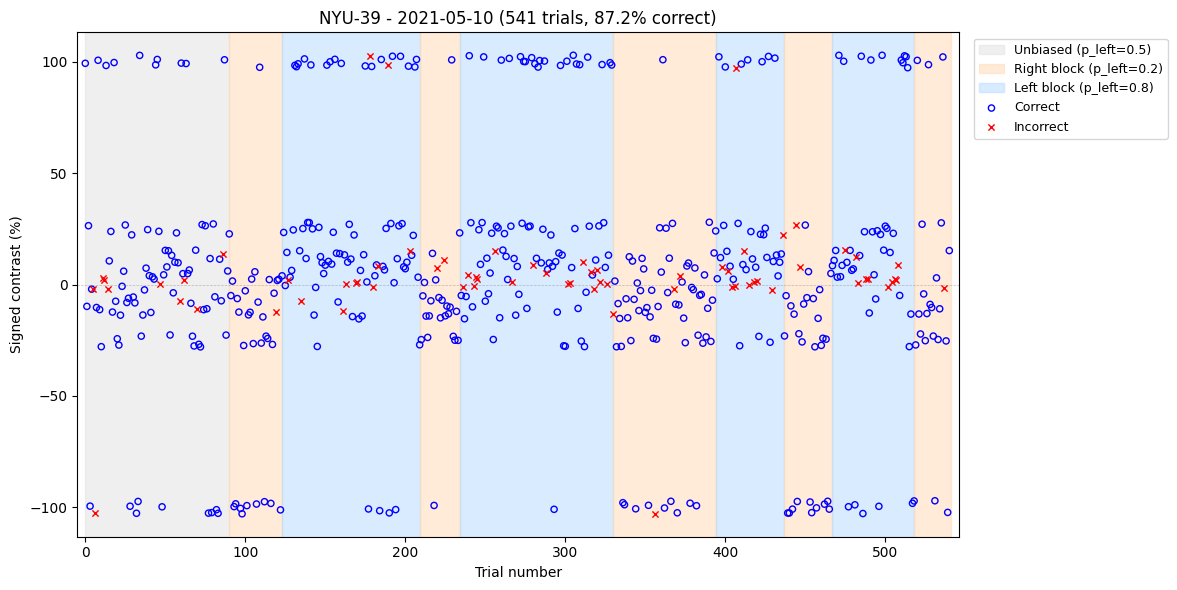

In [30]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# %% Compute signed contrast for y-position
contrast = trials_df["gabor_stimulus_contrast"].values
side = trials_df["gabor_stimulus_side"].values
signed_contrast = np.where(side == "left", contrast, -contrast)
trials_df["signed_contrast"] = signed_contrast

# Add jitter for overlapping points
np.random.seed(42)
trials_df["y_jitter"] = signed_contrast + np.random.uniform(-3, 3, len(trials_df))

# %% Define block background colors
block_bg_colors = {
    "unbiased": "#E0E0E0",
    "left_block": "#B3D9FF",
    "right_block": "#FFD9B3",
}
block_labels = {
    "unbiased": "Unbiased (p_left=0.5)",
    "left_block": "Left block (p_left=0.8)",
    "right_block": "Right block (p_left=0.2)",
}

# %% Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Plot block backgrounds
block_changes = trials_df["block_index"].diff().fillna(1) != 0
block_starts = trials_df.index[block_changes].tolist()
block_starts.append(len(trials_df))

added_labels = set()
for i in range(len(block_starts) - 1):
    start_index = block_starts[i]
    end_index = block_starts[i + 1]
    block_type = trials_df.loc[start_index, "block_type"]
    label = block_labels.get(block_type) if block_type not in added_labels else None
    ax.axvspan(
        start_index,
        end_index,
        color=block_bg_colors.get(block_type, "white"),
        alpha=0.5,
        zorder=0,
        label=label,
    )
    added_labels.add(block_type)

# Plot correct trials (blue circles)
correct = trials_df[trials_df["is_mouse_rewarded"]]
ax.scatter(
    correct.index,
    correct["y_jitter"],
    marker="o",
    s=20,
    facecolors="none",
    edgecolors="blue",
    linewidths=1,
    label="Correct",
    zorder=2,
)

# Plot incorrect trials (red X)
incorrect = trials_df[~trials_df["is_mouse_rewarded"]]
ax.scatter(
    incorrect.index,
    incorrect["y_jitter"],
    color="red",
    marker="x",
    s=20,
    linewidths=1,
    label="Incorrect",
    zorder=2,
)

# Formatting
ax.set_xlabel("Trial number")
ax.set_ylabel("Signed contrast (%)")
ax.set_xlim(-5, len(trials_df) + 5)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)

# Session info
subject = nwbfile.subject.subject_id if nwbfile.subject else "Unknown"
session_date = nwbfile.session_start_time.strftime("%Y-%m-%d")
n_correct = len(correct)
performance = n_correct / len(trials_df) * 100

ax.set_title(f"{subject} - {session_date} ({len(trials_df)} trials, {performance:.1f}% correct)")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


### Psychometric Curves

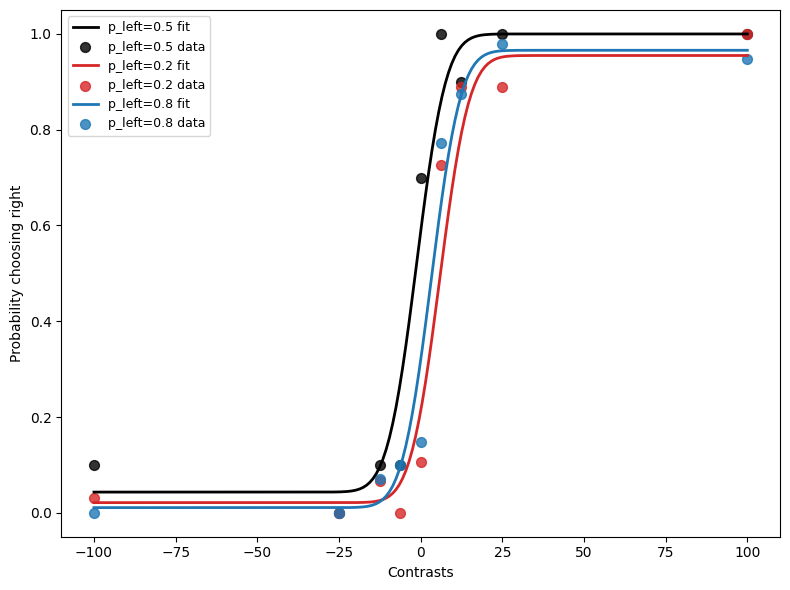

In [31]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import psychofit as psy

# %% Compute signed contrast
# Convention: positive = left stimulus, negative = right stimulus
# This ensures P(choose right) increases with signed contrast
contrast = trials_df["gabor_stimulus_contrast"].values
side = trials_df["gabor_stimulus_side"].values
signed_contrast = np.where(side == "left", contrast, -contrast)

trials_df["signed_contrast"] = signed_contrast
trials_df["chose_right"] = (trials_df["mouse_wheel_choice"] == "right").astype(int)

# %% Define block types and colors (matching IBL style)
blocks = {
    0.5: {"color": "black", "label": "p_left=0.5"},
    0.2: {"color": "tab:red", "label": "p_left=0.2"},
    0.8: {"color": "tab:blue", "label": "p_left=0.8"},
}

# %% Fit and collect data for each block
x_fit = np.linspace(-100, 100, 200)
block_results = {}

for p_left, style in blocks.items():
    block_trials = trials_df[trials_df["probability_left"] == p_left]

    if len(block_trials) == 0:
        print(f"No trials for p_left={p_left}")
        continue

    # Aggregate by contrast
    grouped = (
        block_trials.groupby("signed_contrast")
        .agg(
            n_total=("chose_right", "count"),
            p_right=("chose_right", "mean"),
        )
        .reset_index()
    )

    # Fit psychometric curve
    data = np.vstack(
        [grouped["signed_contrast"].values, grouped["n_total"].values, grouped["p_right"].values]
    )

    pars, _ = psy.mle_fit_psycho(
        data,
        P_model="erf_psycho_2gammas",
        parstart=np.array([0.0, 40.0, 0.1, 0.1]),
        parmin=np.array([-50.0, 10.0, 0.0, 0.0]),
        parmax=np.array([50.0, 50.0, 0.2, 0.2]),
        nfits=10,
    )

    y_fit = psy.erf_psycho_2gammas(pars, x_fit)

    block_results[p_left] = {
        "grouped": grouped,
        "pars": pars,
        "y_fit": y_fit,
        "n_trials": len(block_trials),
    }

# %% Plot psychometric curves for all blocks
fig, ax = plt.subplots(figsize=(8, 6))

for p_left, style in blocks.items():
    if p_left not in block_results:
        continue

    result = block_results[p_left]
    grouped = result["grouped"]
    color = style["color"]
    label = style["label"]

    # Fitted curve
    ax.plot(x_fit, result["y_fit"], color=color, linewidth=2, label=f"{label} fit")

    # Data points
    ax.scatter(
        grouped["signed_contrast"],
        grouped["p_right"],
        color=color,
        s=50,
        alpha=0.8,
        label=f"{label} data",
    )

# Formatting
ax.set_xlabel("Contrasts")
ax.set_ylabel("Probability choosing right")
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()


### Reaction Time by Constrast

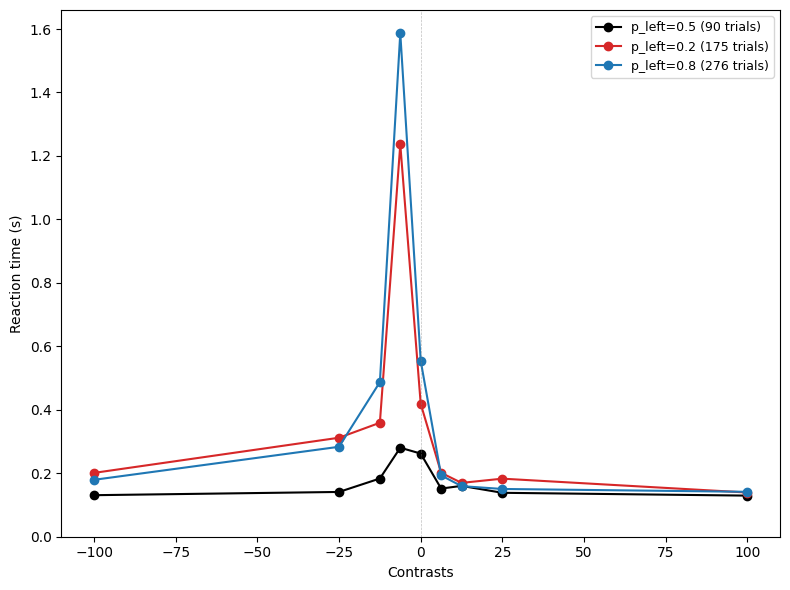

In [32]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from pynwb import read_nwb


# %% Calculate reaction time and signed contrast
trials_df["reaction_time"] = (
    trials_df["wheel_movement_onset_time"] - trials_df["gabor_stimulus_onset_time"]
)

# Signed contrast: positive = left stimulus, negative = right stimulus
contrast = trials_df["gabor_stimulus_contrast"].values
side = trials_df["gabor_stimulus_side"].values
trials_df["signed_contrast"] = np.where(side == "left", contrast, -contrast)

# Get unique contrasts sorted
contrasts = sorted(trials_df["signed_contrast"].unique())

# %% Define block styles (matching IBL and psychometric_curve.py)
blocks = {
    0.5: {"color": "black", "label": "p_left=0.5"},
    0.2: {"color": "tab:red", "label": "p_left=0.2"},
    0.8: {"color": "tab:blue", "label": "p_left=0.8"},
}

# %% Plot reaction time by contrast for each block
fig, ax = plt.subplots(figsize=(8, 6))

for p_left, style in blocks.items():
    block_trials = trials_df[trials_df["probability_left"] == p_left]

    if len(block_trials) == 0:
        continue

    # Calculate median reaction time for each contrast (robust to outliers)
    median_rt = []
    contrast_vals = []

    for c in contrasts:
        contrast_trials = block_trials[block_trials["signed_contrast"] == c]
        if len(contrast_trials) > 0:
            median_rt.append(contrast_trials["reaction_time"].median())
            contrast_vals.append(c)

    ax.plot(
        contrast_vals,
        median_rt,
        "o-",
        color=style["color"],
        label=f"{style['label']} ({len(block_trials)} trials)",
        linewidth=1.5,
        markersize=6,
    )

# Formatting
ax.set_xlabel("Contrasts")
ax.set_ylabel("Reaction time (s)")
ax.set_xlim(-110, 110)
ax.set_ylim(0, None)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()


## Loading Wheel Data

In [33]:
wheel_module = nwbfile_processed.processing["wheel"]
wheel_module

Data type,float64
Shape,"(1076932,)"
Array size,8.22 MiB
Chunk shape,"(1076932,)"
Compression,gzip
Compression opts,4
Uncompressed size (bytes),8615456
Compressed size (bytes),4054330
Compression ratio,2.125001171586921
Data type,float64
Shape,"(1076932,)"


In [34]:
wheel_position = wheel_module["SpatialSeriesWheelPosition"]
wheel_position

Data type,float64
Shape,"(1076932,)"
Array size,8.22 MiB
Chunk shape,"(1076932,)"
Compression,gzip
Compression opts,4
Uncompressed size (bytes),8615456
Compressed size (bytes),4054330
Compression ratio,2.125001171586921
Data type,float64
Shape,"(1076932,)"


## Loading Pose Estimation Data

In [35]:
pose_estimation_module = nwbfile_processed.processing["pose_estimation"]
pose_estimation_module

Data type,float64
Shape,"(109407, 2)"
Array size,1.67 MiB
Chunk shape,"(109407, 2)"
Compression,gzip
Compression opts,4
Uncompressed size (bytes),1750512
Compressed size (bytes),691803
Compression ratio,2.5303619672074276
Data type,float64
Shape,"(109407,)"


In [36]:
left_camera = pose_estimation_module["LeftCamera"]
left_camera

Data type,float64
Shape,"(217894, 2)"
Array size,3.32 MiB
Chunk shape,"(217894, 2)"
Compression,gzip
Compression opts,4
Uncompressed size (bytes),3486304
Compressed size (bytes),803361
Compression ratio,4.339648053614751
Data type,float64
Shape,"(217894,)"


### Overlay Pose on Video

This widget overlays DeepLabCut pose estimation keypoints on the streaming video using [anywidget](https://anywidget.dev/). 

See [documentation/pose_video_widget.md](../documentation/pose_video_widget.md) for details on how the widget works and why it's performant.

In [37]:
import anywidget
import traitlets
import numpy as np

# Get pose estimation container from processed NWB
pose_estimation = nwbfile_processed.processing["pose_estimation"]

# Colors for different keypoints (hex for JavaScript)
keypoint_colors = {
    'LeftPaw': '#FF0000',
    'RightPaw': '#00FF00',
    'NoseTip': '#0000FF',
    'LeftTongueEnd': '#FF00FF',
    'RightTongueEnd': '#CC00CC',
    'TubeTop': '#FFFF00',
    'TubeBottom': '#CCCC00',
    'RightPupilTop': '#00FFFF',
    'RightPupilBottom': '#00CCCC',
    'RightPupilLeft': '#00AAAA',
    'RightPupilRight': '#008888',
}

# Map pose estimation camera names to video acquisition names
camera_name_mapping = {
    'LeftCamera': 'VideoLeftCamera',
    'BodyCamera': 'VideoBodyCamera', 
    'RightCamera': 'VideoRightCamera',
}

# Find available cameras (those with both pose data AND video)
available_pose_cameras = list(pose_estimation.data_interfaces.keys())
camera_to_video = {}
available_cameras = []

for camera_name in available_pose_cameras:
    video_key = camera_name_mapping.get(camera_name)
    video_url = video_s3_urls.get(video_key, '')
    if video_url:
        camera_to_video[camera_name] = video_url
        available_cameras.append(camera_name)

print(f"Available cameras: {available_cameras}")


def load_camera_pose_data(camera_name):
    """Load pose data for a single camera. Called on-demand."""
    camera_pose = pose_estimation[camera_name]
    pose_data = {}
    timestamps = None
    
    for series_name, series in camera_pose.pose_estimation_series.items():
        short_name = series_name.replace("PoseEstimationSeries", "")
        data = series.data[:]
        ts = series.timestamps[:]
        
        if timestamps is None:
            timestamps = ts.tolist()
        
        # Replace NaN with None for JSON serialization
        x_vals = data[:, 0]
        y_vals = data[:, 1]
        x_list = [None if np.isnan(v) else float(v) for v in x_vals]
        y_list = [None if np.isnan(v) else float(v) for v in y_vals]
        
        pose_data[short_name] = {
            'x': x_list,
            'y': y_list,
            'color': keypoint_colors.get(short_name, '#FFFFFF'),
            'label': short_name
        }
    
    return pose_data, timestamps


class PoseVideoPlayer(anywidget.AnyWidget):
    """Video player with pose estimation overlay and camera selector."""
    
    selected_camera = traitlets.Unicode("").tag(sync=True)
    available_cameras = traitlets.List([]).tag(sync=True)
    camera_to_video = traitlets.Dict({}).tag(sync=True)
    
    # Only current camera's data (loaded on demand)
    pose_data = traitlets.Dict({}).tag(sync=True)
    timestamps = traitlets.List([]).tag(sync=True)
    
    show_labels = traitlets.Bool(True).tag(sync=True)
    visible_keypoints = traitlets.Dict({}).tag(sync=True)
    
    _camera_data_cache = {}  # Python-side cache
    
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # Load initial camera data
        if self.selected_camera:
            self._load_camera(self.selected_camera)
        # Watch for camera changes
        self.observe(self._on_camera_change, names=['selected_camera'])
    
    def _load_camera(self, camera_name):
        """Load data for a camera (with caching)."""
        if camera_name not in self._camera_data_cache:
            print(f"Loading pose data for {camera_name}...")
            pose_data, timestamps = load_camera_pose_data(camera_name)
            self._camera_data_cache[camera_name] = (pose_data, timestamps)
            print(f"  Loaded {len(pose_data)} keypoints, {len(timestamps)} frames")
        else:
            pose_data, timestamps = self._camera_data_cache[camera_name]
            print(f"Using cached data for {camera_name}")
        
        self.pose_data = pose_data
        self.timestamps = timestamps
        
        # Initialize visibility for new keypoints
        new_visible = {**self.visible_keypoints}
        for name in pose_data.keys():
            if name not in new_visible:
                new_visible[name] = True
        self.visible_keypoints = new_visible
    
    def _on_camera_change(self, change):
        """Called when selected_camera changes."""
        self._load_camera(change['new'])
    
    _esm = """
    function render({ model, el }) {
        const DISPLAY_WIDTH = 640;
        const DISPLAY_HEIGHT = 512;
        
        const wrapper = document.createElement('div');
        wrapper.style.fontFamily = 'sans-serif';
        
        // Camera selector
        const cameraSelector = document.createElement('div');
        cameraSelector.style.marginBottom = '10px';
        cameraSelector.style.display = 'flex';
        cameraSelector.style.alignItems = 'center';
        cameraSelector.style.gap = '10px';
        
        const cameraLabel = document.createElement('span');
        cameraLabel.textContent = 'Camera:';
        cameraLabel.style.fontWeight = 'bold';
        
        const cameraSelect = document.createElement('select');
        cameraSelect.style.padding = '5px 10px';
        cameraSelect.style.fontSize = '14px';
        
        cameraSelector.appendChild(cameraLabel);
        cameraSelector.appendChild(cameraSelect);
        
        // Debug info
        const debugDiv = document.createElement('div');
        debugDiv.style.backgroundColor = '#f0f0f0';
        debugDiv.style.padding = '5px';
        debugDiv.style.marginBottom = '10px';
        debugDiv.style.fontSize = '12px';
        debugDiv.style.fontFamily = 'monospace';
        
        // Keypoint toggles
        const keypointToggles = document.createElement('div');
        keypointToggles.style.marginBottom = '10px';
        keypointToggles.style.display = 'flex';
        keypointToggles.style.flexWrap = 'wrap';
        keypointToggles.style.gap = '5px';
        
        // Controls
        const controls = document.createElement('div');
        controls.style.marginBottom = '10px';
        controls.style.display = 'flex';
        controls.style.alignItems = 'center';
        controls.style.gap = '10px';
        
        const playPauseBtn = document.createElement('button');
        playPauseBtn.textContent = 'Play';
        playPauseBtn.style.padding = '8px 16px';
        playPauseBtn.style.cursor = 'pointer';
        
        const seekBar = document.createElement('input');
        seekBar.type = 'range';
        seekBar.min = 0;
        seekBar.max = 100;
        seekBar.value = 0;
        seekBar.style.flex = '1';
        
        const labelToggle = document.createElement('label');
        labelToggle.style.display = 'flex';
        labelToggle.style.alignItems = 'center';
        labelToggle.style.gap = '4px';
        labelToggle.style.cursor = 'pointer';
        const checkbox = document.createElement('input');
        checkbox.type = 'checkbox';
        checkbox.checked = model.get('show_labels');
        labelToggle.appendChild(checkbox);
        labelToggle.appendChild(document.createTextNode('Labels'));
        
        controls.appendChild(playPauseBtn);
        controls.appendChild(seekBar);
        controls.appendChild(labelToggle);
        
        // Video container
        const videoContainer = document.createElement('div');
        videoContainer.style.position = 'relative';
        videoContainer.style.width = DISPLAY_WIDTH + 'px';
        videoContainer.style.height = DISPLAY_HEIGHT + 'px';
        
        const video = document.createElement('video');
        video.style.width = DISPLAY_WIDTH + 'px';
        video.style.height = DISPLAY_HEIGHT + 'px';
        video.style.objectFit = 'fill';
        video.style.display = 'block';
        video.style.backgroundColor = '#000';
        video.muted = true;
        video.playsInline = true;
        
        const canvas = document.createElement('canvas');
        canvas.width = DISPLAY_WIDTH;
        canvas.height = DISPLAY_HEIGHT;
        canvas.style.position = 'absolute';
        canvas.style.top = '0';
        canvas.style.left = '0';
        canvas.style.pointerEvents = 'none';
        
        videoContainer.appendChild(video);
        videoContainer.appendChild(canvas);
        
        let isPlaying = false;
        let animationId = null;
        let visibleKeypoints = {...model.get('visible_keypoints')};
        
        function updateDebug(frameIdx, extra = '') {
            const timestamps = model.get('timestamps');
            const camera = model.get('selected_camera');
            debugDiv.textContent = 
                camera + ' | Frame: ' + frameIdx + '/' + timestamps.length +
                ' | Video: ' + video.videoWidth + 'x' + video.videoHeight +
                ' | ' + extra;
        }
        
        function populateCameraSelect() {
            cameraSelect.innerHTML = '';
            const cameras = model.get('available_cameras');
            const selected = model.get('selected_camera');
            cameras.forEach(cam => {
                const opt = document.createElement('option');
                opt.value = cam;
                opt.textContent = cam;
                if (cam === selected) opt.selected = true;
                cameraSelect.appendChild(opt);
            });
        }
        
        function createKeypointToggles() {
            keypointToggles.innerHTML = '';
            const poseData = model.get('pose_data');
            if (!poseData || Object.keys(poseData).length === 0) return;
            
            const allBtn = document.createElement('button');
            allBtn.textContent = 'All';
            allBtn.style.padding = '4px 8px';
            allBtn.style.fontSize = '11px';
            allBtn.style.cursor = 'pointer';
            allBtn.style.backgroundColor = '#ddd';
            allBtn.style.border = '1px solid #999';
            allBtn.style.borderRadius = '3px';
            allBtn.addEventListener('click', () => {
                for (const name of Object.keys(poseData)) visibleKeypoints[name] = true;
                model.set('visible_keypoints', {...visibleKeypoints});
                model.save_changes();
                updateToggleStyles();
                drawPose();
            });
            
            const noneBtn = document.createElement('button');
            noneBtn.textContent = 'None';
            noneBtn.style.padding = '4px 8px';
            noneBtn.style.fontSize = '11px';
            noneBtn.style.cursor = 'pointer';
            noneBtn.style.backgroundColor = '#ddd';
            noneBtn.style.border = '1px solid #999';
            noneBtn.style.borderRadius = '3px';
            noneBtn.addEventListener('click', () => {
                for (const name of Object.keys(poseData)) visibleKeypoints[name] = false;
                model.set('visible_keypoints', {...visibleKeypoints});
                model.save_changes();
                updateToggleStyles();
                drawPose();
            });
            
            keypointToggles.appendChild(allBtn);
            keypointToggles.appendChild(noneBtn);
            
            const sep = document.createElement('span');
            sep.style.borderLeft = '1px solid #ccc';
            sep.style.margin = '0 5px';
            sep.style.height = '20px';
            keypointToggles.appendChild(sep);
            
            for (const [name, kp] of Object.entries(poseData)) {
                const btn = document.createElement('button');
                btn.textContent = name;
                btn.dataset.keypoint = name;
                btn.style.padding = '4px 8px';
                btn.style.fontSize = '11px';
                btn.style.cursor = 'pointer';
                btn.style.borderRadius = '3px';
                btn.style.border = '2px solid ' + kp.color;
                btn.addEventListener('click', () => {
                    visibleKeypoints[name] = !visibleKeypoints[name];
                    model.set('visible_keypoints', {...visibleKeypoints});
                    model.save_changes();
                    updateToggleStyles();
                    drawPose();
                });
                keypointToggles.appendChild(btn);
            }
            updateToggleStyles();
        }
        
        function updateToggleStyles() {
            const buttons = keypointToggles.querySelectorAll('button[data-keypoint]');
            const poseData = model.get('pose_data');
            buttons.forEach(btn => {
                const name = btn.dataset.keypoint;
                const isVisible = visibleKeypoints[name] !== false;
                const color = poseData[name]?.color || '#999';
                btn.style.backgroundColor = isVisible ? color : '#f5f5f5';
                btn.style.color = isVisible ? '#fff' : '#999';
                btn.style.textShadow = isVisible ? '0 0 2px #000' : 'none';
            });
        }
        
        function findFrameIndex(nwbTime) {
            const timestamps = model.get('timestamps');
            if (!timestamps || timestamps.length === 0) return 0;
            let left = 0, right = timestamps.length - 1;
            while (left < right) {
                const mid = Math.floor((left + right) / 2);
                if (timestamps[mid] < nwbTime) left = mid + 1;
                else right = mid;
            }
            return left;
        }
        
        function getFrameIndex() {
            const timestamps = model.get('timestamps');
            if (!timestamps || timestamps.length === 0) return 0;
            return findFrameIndex(timestamps[0] + video.currentTime);
        }
        
        function drawPose() {
            const ctx = canvas.getContext('2d');
            ctx.clearRect(0, 0, canvas.width, canvas.height);
            
            const poseData = model.get('pose_data');
            const showLabels = model.get('show_labels');
            
            if (!poseData || Object.keys(poseData).length === 0) {
                updateDebug(0, 'No pose data');
                return;
            }
            
            const frameIdx = getFrameIndex();
            
            if (!video.videoWidth || !video.videoHeight) {
                updateDebug(frameIdx, 'Loading video...');
                return;
            }
            
            const scaleX = DISPLAY_WIDTH / video.videoWidth;
            const scaleY = DISPLAY_HEIGHT / video.videoHeight;
            
            let drawnCount = 0;
            for (const [name, kp] of Object.entries(poseData)) {
                if (visibleKeypoints[name] === false) continue;
                if (frameIdx >= kp.x.length) continue;
                
                const rawX = kp.x[frameIdx];
                const rawY = kp.y[frameIdx];
                if (rawX === null || rawY === null) continue;
                
                const x = rawX * scaleX;
                const y = rawY * scaleY;
                
                ctx.beginPath();
                ctx.arc(x, y, 5, 0, 2 * Math.PI);
                ctx.fillStyle = kp.color;
                ctx.fill();
                ctx.strokeStyle = '#000';
                ctx.lineWidth = 1.5;
                ctx.stroke();
                drawnCount++;
                
                if (showLabels) {
                    ctx.font = 'bold 10px sans-serif';
                    ctx.fillStyle = '#fff';
                    ctx.strokeStyle = '#000';
                    ctx.lineWidth = 2;
                    ctx.strokeText(kp.label, x + 6, y + 3);
                    ctx.fillText(kp.label, x + 6, y + 3);
                }
            }
            updateDebug(frameIdx, 'Drew ' + drawnCount + ' keypoints');
        }
        
        function animate() {
            drawPose();
            if (isPlaying) animationId = requestAnimationFrame(animate);
        }
        
        function loadVideo() {
            const camera = model.get('selected_camera');
            const videoUrl = model.get('camera_to_video')[camera];
            if (videoUrl && video.src !== videoUrl) {
                video.src = videoUrl;
            }
        }
        
        // Initialize
        populateCameraSelect();
        loadVideo();
        
        video.addEventListener('loadedmetadata', () => {
            const timestamps = model.get('timestamps');
            seekBar.max = timestamps.length - 1;
            drawPose();
        });
        
        video.addEventListener('seeked', drawPose);
        video.addEventListener('timeupdate', drawPose);
        
        // Watch for pose_data changes (when camera switches, Python sends new data)
        model.on('change:pose_data', () => {
            visibleKeypoints = {...model.get('visible_keypoints')};
            createKeypointToggles();
            drawPose();
        });
        
        model.on('change:timestamps', () => {
            const timestamps = model.get('timestamps');
            seekBar.max = timestamps.length - 1;
        });
        
        cameraSelect.addEventListener('change', () => {
            if (isPlaying) {
                video.pause();
                playPauseBtn.textContent = 'Play';
                if (animationId) cancelAnimationFrame(animationId);
                isPlaying = false;
            }
            debugDiv.textContent = 'Loading camera data...';
            model.set('selected_camera', cameraSelect.value);
            model.save_changes();
            loadVideo();
        });
        
        playPauseBtn.addEventListener('click', () => {
            if (isPlaying) {
                video.pause();
                playPauseBtn.textContent = 'Play';
                if (animationId) cancelAnimationFrame(animationId);
            } else {
                video.play();
                playPauseBtn.textContent = 'Pause';
                animate();
            }
            isPlaying = !isPlaying;
        });
        
        seekBar.addEventListener('input', () => {
            const frameIdx = parseInt(seekBar.value);
            const timestamps = model.get('timestamps');
            if (timestamps.length > 0) {
                video.currentTime = timestamps[frameIdx] - timestamps[0];
            }
        });
        
        checkbox.addEventListener('change', () => {
            model.set('show_labels', checkbox.checked);
            model.save_changes();
            drawPose();
        });
        
        updateDebug(0, 'Initializing...');
        
        wrapper.appendChild(cameraSelector);
        wrapper.appendChild(debugDiv);
        wrapper.appendChild(keypointToggles);
        wrapper.appendChild(controls);
        wrapper.appendChild(videoContainer);
        el.appendChild(wrapper);
    }
    export default { render };
    """


# Create widget if cameras available
if available_cameras:
    default_camera = available_cameras[0]
    widget = PoseVideoPlayer(
        selected_camera=default_camera,
        available_cameras=available_cameras,
        camera_to_video=camera_to_video,
    )
else:
    widget = None
    print("No cameras with both pose data and video available.")

widget

Available cameras: ['BodyCamera', 'LeftCamera', 'RightCamera']
Loading pose data for BodyCamera...
  Loaded 1 keypoints, 109407 frames


## Loading Passive Data

In [38]:
passive_module = nwbfile_processed.processing["passive_protocol"]
passive_module

passive_protocol pynwb.base.ProcessingModule at 0x14615553808
Fields:
  data_interfaces: {
    gabor_table <class 'pynwb.epoch.TimeIntervals'>,
    passive_intervals <class 'pynwb.epoch.TimeIntervals'>,
    passive_task_replay <class 'pynwb.epoch.TimeIntervals'>
  }
  description: Data from the IBL passive stimulus protocol, presented at the end of each recording session while the mouse is disengaged from the task. The protocol consists of three phases: (1) spontaneous activity with no stimuli, (2) receptive field mapping (RFM) using sparse noise visual stimuli, and (3) task replay presenting the same Gabor patches and auditory stimuli (valve, tone, noise) used during the active behavioral task. Data revision: 2025-12-04.

In [39]:
gabor_table = passive_module["gabor_table"]
gabor_table

,start_time,stop_time,position,contrast,phase
id,,,,,
0,3304.235177,3304.530247,35.0,0.0625,0.728452
1,3305.868613,3306.180016,35.0,1.0000,0.546884
2,3307.401893,3307.713496,35.0,0.0625,0.126099
3,3309.768423,3310.063394,35.0,0.1250,2.741382


In [40]:
passive_intervals = passive_module["passive_intervals"]
passive_intervals

,start_time,stop_time,protocol_name
id,,,
0,2368.310125,2968.384718,spontaneousActivity
1,3293.980383,3637.565807,taskReplay


In [41]:
passive_task_replay = passive_module["passive_task_replay"]
passive_task_replay

,start_time,stop_time,stim_type
id,,,
0,3302.473053,3302.973070,noise
1,3304.990701,3305.090725,tone
2,3306.485052,3306.585042,tone
3,3307.687698,3307.715695,valve


## Trial-Aligned Behavioral Data

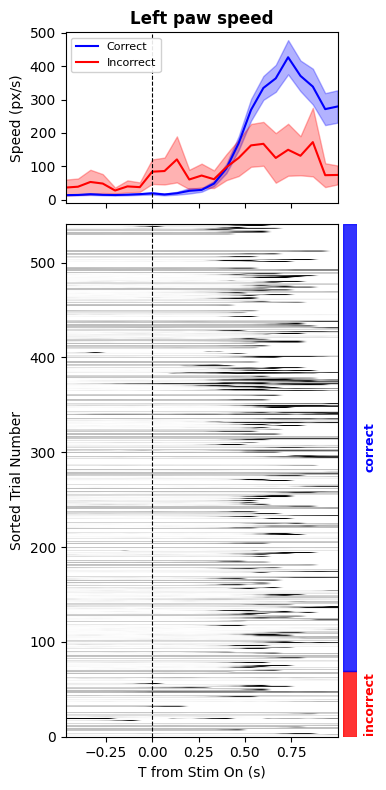

In [42]:
# Trial-aligned left paw speed with correct/incorrect trial separation
import pynapple as nap

# Load with pynapple from memory
data = nap.NWBFile(nwbfile_processed)

# Get trials dataframe for metadata
trials_df = nwbfile_processed.trials.to_dataframe()

# Masks for correct/incorrect
correct_mask = trials_df['is_mouse_rewarded'].values

# Get left paw position and compute speed using pynapple's derivative
left_paw = data['LeftCamera/PoseEstimationSeriesLeftPaw']
velocity = left_paw.derivative()
speed_values = np.sqrt(velocity.values[:, 0]**2 + velocity.values[:, 1]**2)
speed = nap.Tsd(t=velocity.t, d=speed_values)

# Create Ts objects for stimulus onset times
stim_times = nap.Ts(t=trials_df['gabor_stimulus_onset_time'].values)
correct_stim_times = nap.Ts(t=trials_df.loc[correct_mask, 'gabor_stimulus_onset_time'].values)
incorrect_stim_times = nap.Ts(t=trials_df.loc[~correct_mask, 'gabor_stimulus_onset_time'].values)

# Use pynapple's compute_perievent_continuous to align speed around stimulus onset
minmax = (-0.5, 1.0)  # 0.5s before to 1s after stimulus

perievent_all = nap.compute_perievent_continuous(speed, stim_times, minmax=minmax)
perievent_correct = nap.compute_perievent_continuous(speed, correct_stim_times, minmax=minmax)
perievent_incorrect = nap.compute_perievent_continuous(speed, incorrect_stim_times, minmax=minmax)

# Compute mean and SEM
correct_mean = np.nanmean(perievent_correct.values, axis=1)
correct_sem = np.nanstd(perievent_correct.values, axis=1) / np.sqrt(np.sum(~np.isnan(perievent_correct.values), axis=1))
incorrect_mean = np.nanmean(perievent_incorrect.values, axis=1)
incorrect_sem = np.nanstd(perievent_incorrect.values, axis=1) / np.sqrt(np.sum(~np.isnan(perievent_incorrect.values), axis=1))

time = perievent_correct.t

# Sort trials by outcome for raster
sorted_indices = np.argsort(correct_mask)
perievent_sorted = perievent_all.values[:, sorted_indices]

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(4, 8), gridspec_kw={'height_ratios': [1, 3]}, sharex=True)

ax_avg = axes[0]
ax_avg.plot(time, correct_mean, color='blue', linewidth=1.5, label='Correct')
ax_avg.fill_between(time, correct_mean - correct_sem, correct_mean + correct_sem, color='blue', alpha=0.3)
ax_avg.plot(time, incorrect_mean, color='red', linewidth=1.5, label='Incorrect')
ax_avg.fill_between(time, incorrect_mean - incorrect_sem, incorrect_mean + incorrect_sem, color='red', alpha=0.3)
ax_avg.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax_avg.set_ylabel('Speed (px/s)')
ax_avg.set_title('Left paw speed', fontsize=12, fontweight='bold', loc='center')
ax_avg.legend(loc='upper left', fontsize=8, framealpha=0.9)

ax_raster = axes[1]
n_trials = perievent_sorted.shape[1]
n_incorrect = (~correct_mask).sum()
n_correct = correct_mask.sum()

im = ax_raster.imshow(perievent_sorted.T, aspect='auto', cmap='gray_r',
                       extent=[time[0], time[-1], 0, n_trials],
                       vmin=0, vmax=np.nanpercentile(perievent_sorted, 95),
                       origin='lower')

# Side color bar
bar_width = 0.05
ax_bar = ax_raster.inset_axes([1.02, 0, bar_width, 1])
ax_bar.axhspan(0, n_incorrect / n_trials, color='red', alpha=0.8)
ax_bar.axhspan(n_incorrect / n_trials, 1, color='blue', alpha=0.8)
ax_bar.set_xlim(0, 1)
ax_bar.set_ylim(0, 1)
ax_bar.axis('off')
ax_bar.text(1.5, (n_incorrect / n_trials) / 2, 'incorrect', rotation=90, va='center', ha='left', fontsize=9, color='red', fontweight='bold')
ax_bar.text(1.5, n_incorrect / n_trials + (n_correct / n_trials) / 2, 'correct', rotation=90, va='center', ha='left', fontsize=9, color='blue', fontweight='bold')

ax_raster.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax_raster.set_ylabel('Sorted Trial Number')
ax_raster.set_xlabel('T from Stim On (s)')

plt.tight_layout()
plt.show()

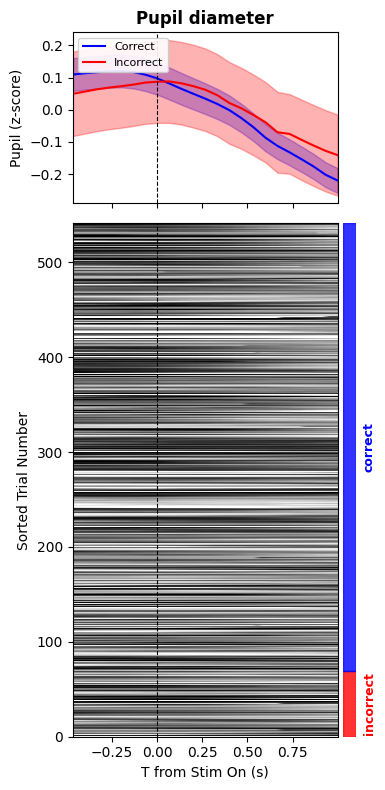

In [43]:
# Trial-aligned pupil diameter (z-scored) with correct/incorrect trial separation

# Get smoothed pupil diameter
pupil = data['TimeSeriesLeftSmoothedPupilDiameter']

# Create Ts objects for stimulus onset times
stim_times = nap.Ts(t=trials_df['gabor_stimulus_onset_time'].values)
correct_stim_times = nap.Ts(t=trials_df.loc[correct_mask, 'gabor_stimulus_onset_time'].values)
incorrect_stim_times = nap.Ts(t=trials_df.loc[~correct_mask, 'gabor_stimulus_onset_time'].values)

minmax = (-0.5, 1.0)

perievent_all = nap.compute_perievent_continuous(pupil, stim_times, minmax=minmax)
perievent_correct = nap.compute_perievent_continuous(pupil, correct_stim_times, minmax=minmax)
perievent_incorrect = nap.compute_perievent_continuous(pupil, incorrect_stim_times, minmax=minmax)

# Z-score the data for visualization
all_values = perievent_all.values.flatten()
all_values = all_values[~np.isnan(all_values)]
mean_val = np.mean(all_values)
std_val = np.std(all_values)

perievent_all_z = (perievent_all.values - mean_val) / std_val
perievent_correct_z = (perievent_correct.values - mean_val) / std_val
perievent_incorrect_z = (perievent_incorrect.values - mean_val) / std_val

# Compute mean and SEM
correct_mean = np.nanmean(perievent_correct_z, axis=1)
correct_sem = np.nanstd(perievent_correct_z, axis=1) / np.sqrt(np.sum(~np.isnan(perievent_correct_z), axis=1))
incorrect_mean = np.nanmean(perievent_incorrect_z, axis=1)
incorrect_sem = np.nanstd(perievent_incorrect_z, axis=1) / np.sqrt(np.sum(~np.isnan(perievent_incorrect_z), axis=1))

time = perievent_correct.t

# Sort trials by outcome for raster
sorted_indices = np.argsort(correct_mask)
perievent_sorted = perievent_all_z[:, sorted_indices]

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(4, 8), gridspec_kw={'height_ratios': [1, 3]}, sharex=True)

ax_avg = axes[0]
ax_avg.plot(time, correct_mean, color='blue', linewidth=1.5, label='Correct')
ax_avg.fill_between(time, correct_mean - correct_sem, correct_mean + correct_sem, color='blue', alpha=0.3)
ax_avg.plot(time, incorrect_mean, color='red', linewidth=1.5, label='Incorrect')
ax_avg.fill_between(time, incorrect_mean - incorrect_sem, incorrect_mean + incorrect_sem, color='red', alpha=0.3)
ax_avg.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax_avg.set_ylabel('Pupil (z-score)')
ax_avg.set_title('Pupil diameter', fontsize=12, fontweight='bold', loc='center')
ax_avg.legend(loc='upper left', fontsize=8, framealpha=0.9)

ax_raster = axes[1]
n_trials = perievent_sorted.shape[1]
n_incorrect = (~correct_mask).sum()
n_correct = correct_mask.sum()

im = ax_raster.imshow(perievent_sorted.T, aspect='auto', cmap='gray_r',
                       extent=[time[0], time[-1], 0, n_trials],
                       vmin=np.nanpercentile(perievent_sorted, 5),
                       vmax=np.nanpercentile(perievent_sorted, 95),
                       origin='lower')

# Side color bar
bar_width = 0.05
ax_bar = ax_raster.inset_axes([1.02, 0, bar_width, 1])
ax_bar.axhspan(0, n_incorrect / n_trials, color='red', alpha=0.8)
ax_bar.axhspan(n_incorrect / n_trials, 1, color='blue', alpha=0.8)
ax_bar.set_xlim(0, 1)
ax_bar.set_ylim(0, 1)
ax_bar.axis('off')
ax_bar.text(1.5, (n_incorrect / n_trials) / 2, 'incorrect', rotation=90, va='center', ha='left', fontsize=9, color='red', fontweight='bold')
ax_bar.text(1.5, n_incorrect / n_trials + (n_correct / n_trials) / 2, 'correct', rotation=90, va='center', ha='left', fontsize=9, color='blue', fontweight='bold')

ax_raster.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax_raster.set_ylabel('Sorted Trial Number')
ax_raster.set_xlabel('T from Stim On (s)')

plt.tight_layout()
plt.show()

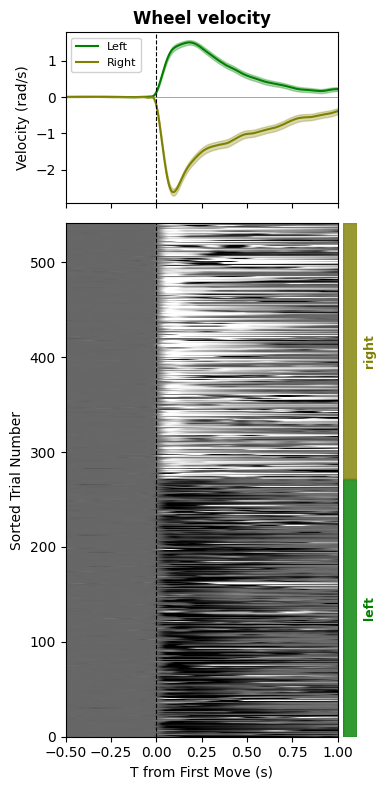

In [44]:
# Trial-aligned wheel velocity sorted by choice (left/right), aligned to first movement onset

# Masks for left/right choices
left_choice_mask = trials_df['mouse_wheel_choice'].values == 'left'
right_choice_mask = trials_df['mouse_wheel_choice'].values == 'right'

# Get wheel velocity (in rad/s)
wheel_velocity = data['TimeSeriesWheelVelocity']

# Create Ts objects for first movement times, separated by choice
movement_times = nap.Ts(t=trials_df['wheel_movement_onset_time'].values)
left_movement_times = nap.Ts(t=trials_df.loc[left_choice_mask, 'wheel_movement_onset_time'].values)
right_movement_times = nap.Ts(t=trials_df.loc[right_choice_mask, 'wheel_movement_onset_time'].values)

minmax = (-0.5, 1.0)

perievent_all = nap.compute_perievent_continuous(wheel_velocity, movement_times, minmax=minmax)
perievent_left = nap.compute_perievent_continuous(wheel_velocity, left_movement_times, minmax=minmax)
perievent_right = nap.compute_perievent_continuous(wheel_velocity, right_movement_times, minmax=minmax)

# Compute mean and SEM
left_mean = np.nanmean(perievent_left.values, axis=1)
left_sem = np.nanstd(perievent_left.values, axis=1) / np.sqrt(np.sum(~np.isnan(perievent_left.values), axis=1))
right_mean = np.nanmean(perievent_right.values, axis=1)
right_sem = np.nanstd(perievent_right.values, axis=1) / np.sqrt(np.sum(~np.isnan(perievent_right.values), axis=1))

time = perievent_left.t

# Sort trials by choice for raster (left first, then right)
sorted_indices = np.argsort(right_choice_mask)  # False (left) first, then True (right)
perievent_sorted = perievent_all.values[:, sorted_indices]

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(4, 8), gridspec_kw={'height_ratios': [1, 3]}, sharex=True)

ax_avg = axes[0]
ax_avg.plot(time, left_mean, color='green', linewidth=1.5, label='Left')
ax_avg.fill_between(time, left_mean - left_sem, left_mean + left_sem, color='green', alpha=0.3)
ax_avg.plot(time, right_mean, color='olive', linewidth=1.5, label='Right')
ax_avg.fill_between(time, right_mean - right_sem, right_mean + right_sem, color='olive', alpha=0.3)
ax_avg.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax_avg.axhline(0, color='gray', linestyle='-', linewidth=0.5)
ax_avg.set_ylabel('Velocity (rad/s)')
ax_avg.set_title('Wheel velocity', fontsize=12, fontweight='bold', loc='center')
ax_avg.legend(loc='upper left', fontsize=8, framealpha=0.9)

ax_raster = axes[1]
n_trials = perievent_sorted.shape[1]
n_left = left_choice_mask.sum()
n_right = right_choice_mask.sum()

im = ax_raster.imshow(perievent_sorted.T, aspect='auto', cmap='gray_r',
                       extent=[time[0], time[-1], 0, n_trials],
                       vmin=np.nanpercentile(perievent_sorted, 5),
                       vmax=np.nanpercentile(perievent_sorted, 95),
                       origin='lower')

# Side color bar for left/right choice
bar_width = 0.05
ax_bar = ax_raster.inset_axes([1.02, 0, bar_width, 1])
ax_bar.axhspan(0, n_left / n_trials, color='green', alpha=0.8)
ax_bar.axhspan(n_left / n_trials, 1, color='olive', alpha=0.8)
ax_bar.set_xlim(0, 1)
ax_bar.set_ylim(0, 1)
ax_bar.axis('off')
ax_bar.text(1.5, (n_left / n_trials) / 2, 'left', rotation=90, va='center', ha='left', fontsize=9, color='green', fontweight='bold')
ax_bar.text(1.5, n_left / n_trials + (n_right / n_trials) / 2, 'right', rotation=90, va='center', ha='left', fontsize=9, color='olive', fontweight='bold')

ax_raster.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax_raster.set_ylabel('Sorted Trial Number')
ax_raster.set_xlabel('T from First Move (s)')

plt.tight_layout()
plt.show()

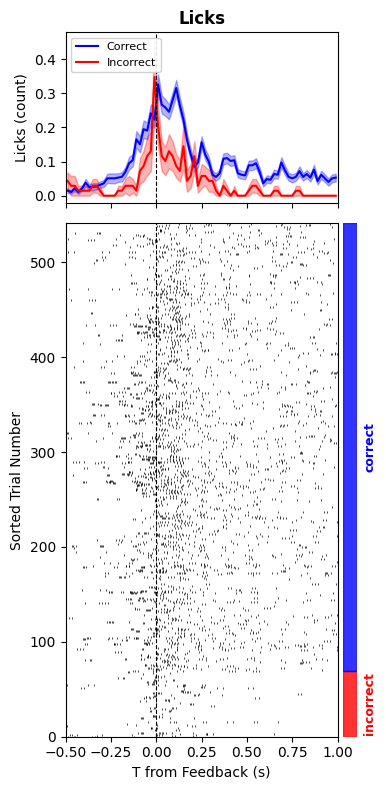

In [45]:
# Trial-aligned lick counts with correct/incorrect trial separation, aligned to feedback time

# Get lick timestamps from processing module
lick_events = nwbfile_processed.processing['lick_times']['EventsLickTimes']
lick_times = nap.Ts(t=lick_events.timestamps[:])

# Create Ts objects for feedback times
feedback_times = nap.Ts(t=trials_df['feedback_time'].values)
correct_feedback_times = nap.Ts(t=trials_df.loc[correct_mask, 'feedback_time'].values)
incorrect_feedback_times = nap.Ts(t=trials_df.loc[~correct_mask, 'feedback_time'].values)

minmax = (-0.5, 1.0)
bin_size = 0.02  # 20ms bins for counting

# Use compute_perievent to align lick timestamps around feedback
perievent_licks = nap.compute_perievent(lick_times, feedback_times, minmax=minmax)

# For the average trace, we need to count licks in bins
perievent_correct_licks = nap.compute_perievent(lick_times, correct_feedback_times, minmax=minmax)
perievent_incorrect_licks = nap.compute_perievent(lick_times, incorrect_feedback_times, minmax=minmax)

# Count licks in bins for average traces
correct_counts = perievent_correct_licks.count(bin_size)
incorrect_counts = perievent_incorrect_licks.count(bin_size)

# Mean across trials (columns are trials in the TsGroup)
correct_mean = np.nanmean(correct_counts.values, axis=1)
correct_sem = np.nanstd(correct_counts.values, axis=1) / np.sqrt(correct_counts.shape[1])
incorrect_mean = np.nanmean(incorrect_counts.values, axis=1)
incorrect_sem = np.nanstd(incorrect_counts.values, axis=1) / np.sqrt(incorrect_counts.shape[1])

time_counts = correct_counts.t

# Sort trials by outcome
sorted_trial_indices = np.argsort(correct_mask)

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(4, 8), gridspec_kw={'height_ratios': [1, 3]}, sharex=True)

ax_avg = axes[0]
ax_avg.plot(time_counts, correct_mean, color='blue', linewidth=1.5, label='Correct')
ax_avg.fill_between(time_counts, correct_mean - correct_sem, correct_mean + correct_sem, color='blue', alpha=0.3)
ax_avg.plot(time_counts, incorrect_mean, color='red', linewidth=1.5, label='Incorrect')
ax_avg.fill_between(time_counts, incorrect_mean - incorrect_sem, incorrect_mean + incorrect_sem, color='red', alpha=0.3)
ax_avg.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax_avg.set_ylabel('Licks (count)')
ax_avg.set_title('Licks', fontsize=12, fontweight='bold', loc='center')
ax_avg.legend(loc='upper left', fontsize=8, framealpha=0.9)

# Raster plot - plot individual lick events
ax_raster = axes[1]

# Plot licks as scatter points for each trial
n_trials = len(trials_df)
n_incorrect = (~correct_mask).sum()
n_correct = correct_mask.sum()

# Get lick times for each trial and plot as raster
for i, sorted_index in enumerate(sorted_trial_indices):
    if sorted_index in perievent_licks.keys():
        trial_licks = perievent_licks[sorted_index]
        if len(trial_licks) > 0:
            ax_raster.scatter(trial_licks.t, np.full(len(trial_licks), i),
                            c='black', s=1, marker='|', linewidths=0.5)

# Side color bar
bar_width = 0.05
ax_bar = ax_raster.inset_axes([1.02, 0, bar_width, 1])
ax_bar.axhspan(0, n_incorrect / n_trials, color='red', alpha=0.8)
ax_bar.axhspan(n_incorrect / n_trials, 1, color='blue', alpha=0.8)
ax_bar.set_xlim(0, 1)
ax_bar.set_ylim(0, 1)
ax_bar.axis('off')
ax_bar.text(1.5, (n_incorrect / n_trials) / 2, 'incorrect', rotation=90, va='center', ha='left', fontsize=9, color='red', fontweight='bold')
ax_bar.text(1.5, n_incorrect / n_trials + (n_correct / n_trials) / 2, 'correct', rotation=90, va='center', ha='left', fontsize=9, color='blue', fontweight='bold')

ax_raster.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax_raster.set_ylabel('Sorted Trial Number')
ax_raster.set_xlabel('T from Feedback (s)')
ax_raster.set_xlim(minmax[0], minmax[1])
ax_raster.set_ylim(0, n_trials)

plt.tight_layout()
plt.show()